<a href="https://colab.research.google.com/github/AjaySreekumar47/vlm-research/blob/main/SAM_MedSAM_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Environment Setup for SAM vs MedSAM Comparison

In [ ]:
# Step 1: Environment Setup for SAM vs MedSAM Comparison
# Run this in Google Colab

# Check if we're in Colab
try:
    import google.colab
    IN_COLAB = True
    print("✓ Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("✗ Not running in Google Colab")

# Install required packages
import subprocess
import sys
import os

def install_package(package):
    """Helper function to install packages"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ Successfully installed {package}")
    except subprocess.CalledProcessError as e:
        print(f"✗ Failed to install {package}: {e}")

# Check if PyTorch is already available (common in Colab)
try:
    import torch
    import torchvision
    print("✓ PyTorch already available")
    torch_available = True
except ImportError:
    print("Installing PyTorch...")
    install_package("torch torchvision")
    torch_available = False

# Install other core packages
other_packages = [
    "opencv-python",
    "matplotlib",
    "numpy",
    "Pillow",
    "scikit-image",
    "tqdm",
    "requests",
    "gdown"  # For downloading files from Google Drive
]

print("Installing other required packages...")
for package in other_packages:
    install_package(package)

# Install SAM
print("\nInstalling Segment Anything Model (SAM)...")
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/facebookresearch/segment-anything.git"])
    print("✓ Successfully installed SAM")
except subprocess.CalledProcessError as e:
    print(f"✗ Failed to install SAM: {e}")

# Install MedSAM
print("\nInstalling MedSAM...")
try:
    # Check if MedSAM directory already exists
    if not os.path.exists("MedSAM"):
        subprocess.check_call(["git", "clone", "https://github.com/bowang-lab/MedSAM.git"])
        print("✓ Successfully cloned MedSAM repository")
    else:
        print("✓ MedSAM repository already exists")

    # Install MedSAM requirements manually (avoiding conflicts)
    medsam_packages = [
        "monai",
        "connected-components-3d",
        "SimpleITK"
    ]

    for pkg in medsam_packages:
        try:
            install_package(pkg)
        except:
            print(f"⚠ Could not install {pkg}, continuing...")

    print("✓ MedSAM dependencies installed")

except subprocess.CalledProcessError as e:
    print(f"✗ Failed to setup MedSAM: {e}")
    print("Continuing without MedSAM for now...")

# Import basic libraries to verify installation
print("\nVerifying installations...")
try:
    import torch
    import torchvision
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    print("✓ All basic libraries imported successfully")

    # Check CUDA availability
    if torch.cuda.is_available():
        print(f"✓ CUDA is available. Device: {torch.cuda.get_device_name(0)}")
        device = "cuda"
    else:
        print("⚠ CUDA not available. Will use CPU (slower)")
        device = "cpu"

    print(f"Using device: {device}")

    # Test SAM import
    try:
        from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
        print("✓ SAM successfully imported")
    except ImportError as e:
        print(f"⚠ SAM import failed: {e}")

    # Check MedSAM availability
    if os.path.exists("MedSAM"):
        print("✓ MedSAM repository available")
        # Add MedSAM to Python path
        import sys
        if "MedSAM" not in sys.path:
            sys.path.append("MedSAM")
    else:
        print("⚠ MedSAM repository not found")

except ImportError as e:
    print(f"✗ Import error: {e}")

print("\n" + "="*50)
print("Environment setup complete!")
print("="*50)

✓ Running in Google Colab
✓ PyTorch already available
Installing other required packages...
✓ Successfully installed opencv-python
✓ Successfully installed matplotlib
✓ Successfully installed numpy
✓ Successfully installed Pillow
✓ Successfully installed scikit-image
✓ Successfully installed tqdm
✓ Successfully installed requests
✓ Successfully installed gdown

Installing Segment Anything Model (SAM)...
✓ Successfully installed SAM

Installing MedSAM...
✓ Successfully cloned MedSAM repository
✓ Successfully installed monai
✓ Successfully installed connected-components-3d
✓ Successfully installed SimpleITK
✓ MedSAM dependencies installed

Verifying installations...
✓ All basic libraries imported successfully
✓ CUDA is available. Device: Tesla T4
Using device: cuda
✓ SAM successfully imported
✓ MedSAM repository available

Environment setup complete!


# Step 2: Download Model Weights and Initialize Models. This code will:

- 📥 Download SAM ViT-H weights (2.4GB) : the highest performance SAM model
-📥 Download MedSAM weights (400MB) : the medical fine-tuned version
-🔧 Initialize both models with proper device placement
-📊 Create predictors for both models ready for inference
-✅ Verify everything is working and show model parameter counts

Important notes:

-The downloads will take several minutes (especially SAM weights)
-Files are saved to a weights/ directory for reuse
-The code checks if files already exist to avoid re-downloading

In [ ]:
# Step 2: Download Model Weights and Initialize SAM vs MedSAM
import torch
import os
import requests
from tqdm import tqdm
import gdown

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def download_file(url, filename, description=""):
    """Download file with progress bar"""
    if os.path.exists(filename):
        print(f"✓ {filename} already exists")
        return True

    print(f"Downloading {description}...")
    try:
        if "drive.google.com" in url:
            # Use gdown for Google Drive links
            gdown.download(url, filename, quiet=False)
        elif "huggingface.co" in url:
            # Direct download for HuggingFace
            response = requests.get(url, stream=True)
            response.raise_for_status()

            total_size = int(response.headers.get('content-length', 0))

            with open(filename, 'wb') as file, tqdm(
                desc=description,
                total=total_size,
                unit='B',
                unit_scale=True,
                unit_divisor=1024,
            ) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    size = file.write(chunk)
                    pbar.update(size)
        else:
            # Use requests for other direct links (including Zenodo)
            response = requests.get(url, stream=True, allow_redirects=True)
            response.raise_for_status()

            total_size = int(response.headers.get('content-length', 0))

            with open(filename, 'wb') as file, tqdm(
                desc=description,
                total=total_size,
                unit='B',
                unit_scale=True,
                unit_divisor=1024,
            ) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    size = file.write(chunk)
                    pbar.update(size)

        print(f"✓ Successfully downloaded {filename}")
        return True
    except Exception as e:
        print(f"✗ Failed to download {filename}: {e}")
        return False

# Create weights directory
os.makedirs("weights", exist_ok=True)

# Install transformers for potential HuggingFace fallback
try:
    install_package("transformers")
    print("✓ Transformers library available")
except:
    print("⚠ Could not install transformers library")

print("="*60)
print("DOWNLOADING MODEL WEIGHTS")
print("="*60)

# 1. Download SAM weights (ViT-H model - highest performance)
print("\n1. Downloading SAM ViT-H weights...")
sam_weight_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
sam_weight_path = "weights/sam_vit_h_4b8939.pth"
sam_downloaded = download_file(sam_weight_url, sam_weight_path, "SAM ViT-H weights")

# 2. Download MedSAM weights
print("\n2. Downloading MedSAM weights...")
# Official MedSAM weight file from Zenodo (the correct source)
medsam_weight_url = "https://zenodo.org/records/10689643/files/medsam_vit_b.pth?download=1"
medsam_weight_path = "weights/medsam_vit_b.pth"

# Alternative: Download from Hugging Face if Zenodo fails
medsam_hf_url = "https://huggingface.co/flaviagiammarino/medsam-vit-base/resolve/main/pytorch_model.bin"

# Try Zenodo first, then HuggingFace as backup
medsam_downloaded = download_file(medsam_weight_url, medsam_weight_path, "MedSAM weights (Zenodo)")

if not medsam_downloaded:
    print("Trying alternative download from HuggingFace...")
    medsam_downloaded = download_file(medsam_hf_url, medsam_weight_path, "MedSAM weights (HuggingFace)")

print("\n" + "="*60)
print("INITIALIZING MODELS")
print("="*60)

# 3. Initialize SAM model
print("\n1. Initializing SAM model...")
try:
    from segment_anything import sam_model_registry, SamPredictor

    if sam_downloaded and os.path.exists(sam_weight_path):
        sam_model = sam_model_registry["vit_h"](checkpoint=sam_weight_path)
        sam_model.to(device)
        sam_predictor = SamPredictor(sam_model)
        print("✓ SAM model loaded successfully")
        sam_available = True
    else:
        print("✗ SAM weights not available")
        sam_available = False
        sam_predictor = None

except Exception as e:
    print(f"✗ Failed to initialize SAM: {e}")
    sam_available = False
    sam_predictor = None

# 4. Initialize MedSAM model
print("\n2. Initializing MedSAM model...")
try:
    # Add MedSAM to path if not already added
    import sys
    if "MedSAM" not in sys.path:
        sys.path.append("MedSAM")

    # Import MedSAM specific modules
    from segment_anything import sam_model_registry
    from segment_anything.utils.transforms import ResizeLongestSide

    if medsam_downloaded and os.path.exists(medsam_weight_path):
        # MedSAM uses ViT-B architecture
        medsam_model = sam_model_registry["vit_b"](checkpoint=medsam_weight_path)
        medsam_model.to(device)

        # MedSAM predictor setup
        medsam_predictor = SamPredictor(medsam_model)
        print("✓ MedSAM model loaded successfully")
        medsam_available = True
    else:
        print("✗ MedSAM weights not available, trying HuggingFace alternative...")

        # Try loading from HuggingFace transformers as backup
        try:
            from transformers import SamModel, SamProcessor
            medsam_model = SamModel.from_pretrained("flaviagiammarino/medsam-vit-base").to(device)
            medsam_processor = SamProcessor.from_pretrained("flaviagiammarino/medsam-vit-base")

            # Create a wrapper to make it compatible with SamPredictor interface
            class MedSAMPredictor:
                def __init__(self, model, processor):
                    self.model = model
                    self.processor = processor
                    self.device = device

                def set_image(self, image):
                    self.image = image
                    # Store for later use in predict

                def predict(self, point_coords=None, point_labels=None, box=None, multimask_output=True):
                    if box is not None:
                        # Convert box to the expected format
                        inputs = self.processor(self.image, input_boxes=[[box]], return_tensors="pt").to(self.device)
                        outputs = self.model(**inputs, multimask_output=multimask_output)

                        # Extract masks and convert to numpy
                        masks = outputs.pred_masks.sigmoid().cpu().numpy()
                        scores = outputs.iou_predictions.cpu().numpy()

                        return masks, scores, None
                    else:
                        raise NotImplementedError("Point prompts not implemented for HuggingFace version")

            medsam_predictor = MedSAMPredictor(medsam_model, medsam_processor)
            print("✓ MedSAM model loaded from HuggingFace successfully")
            medsam_available = True
        except Exception as hf_error:
            print(f"✗ HuggingFace fallback also failed: {hf_error}")
            medsam_available = False
            medsam_predictor = None

except Exception as e:
    print(f"✗ Failed to initialize MedSAM: {e}")
    medsam_available = False
    medsam_predictor = None

# 5. Summary
print("\n" + "="*60)
print("MODEL INITIALIZATION SUMMARY")
print("="*60)
print(f"SAM (ViT-H):     {'✓ Ready' if sam_available else '✗ Not available'}")
print(f"MedSAM (ViT-B):  {'✓ Ready' if medsam_available else '✗ Not available'}")
print(f"Device:          {device}")

if sam_available or medsam_available:
    print("\n✓ At least one model is ready for comparison!")
else:
    print("\n✗ No models available. Please check downloads and try again.")

# 6. Model info function
def get_model_info():
    """Display detailed model information"""
    print("\nModel Details:")
    if sam_available:
        total_params = sum(p.numel() for p in sam_model.parameters())
        print(f"SAM ViT-H: {total_params:,} parameters")
    if medsam_available:
        try:
            # Try to get parameters from the model
            if hasattr(medsam_predictor, 'model'):
                if hasattr(medsam_predictor.model, 'parameters'):
                    total_params = sum(p.numel() for p in medsam_predictor.model.parameters())
                else:
                    # For HuggingFace models
                    total_params = sum(p.numel() for p in medsam_model.parameters())
            else:
                total_params = sum(p.numel() for p in medsam_model.parameters())
            print(f"MedSAM ViT-B: {total_params:,} parameters")
        except:
            print("MedSAM ViT-B: Parameter count unavailable")

get_model_info()

Using device: cuda
✓ Successfully installed transformers
✓ Transformers library available
DOWNLOADING MODEL WEIGHTS

1. Downloading SAM ViT-H weights...


SAM ViT-H weights: 100%|██████████| 2.39G/2.39G [00:28<00:00, 89.2MB/s]


✓ Successfully downloaded weights/sam_vit_h_4b8939.pth

2. Downloading MedSAM weights...


MedSAM weights (Zenodo): 100%|██████████| 358M/358M [00:24<00:00, 15.4MB/s]


✓ Successfully downloaded weights/medsam_vit_b.pth

INITIALIZING MODELS

1. Initializing SAM model...
✓ SAM model loaded successfully

2. Initializing MedSAM model...
✓ MedSAM model loaded successfully

MODEL INITIALIZATION SUMMARY
SAM (ViT-H):     ✓ Ready
MedSAM (ViT-B):  ✓ Ready
Device:          cuda

✓ At least one model is ready for comparison!

Model Details:
SAM ViT-H: 641,090,608 parameters
MedSAM ViT-B: 93,735,472 parameters


# Step 3: Dataset Preparation

This code will:
- 🔽 Download your entire Google Drive folder using the ID you provided
-📁 Explore the directory structure recursively
-🔍 Categorize files into images, masks, and other types
-🔗 Identify image-mask pairs automatically using naming patterns
-📊 Visualize sample data to verify everything loaded correctly
-📋 Prepare dataset info for the SAM vs MedSAM comparison

##Key features:

- Multiple download methods - tries different approaches if one fails
-Smart file detection - identifies images vs masks by name/content
-Automatic pairing - matches images to their corresponding masks
-Visual verification - shows sample image-mask pairs
-Error handling - continues even if some steps fail

It will automatically:

- Download your dataset from the Google Drive link
-Show you the complete folder structure
-Tell you how many image-mask pairs it found
-Display a sample visualization

In [ ]:
# Step 3: Dataset Preparation - Explore EndoVis2017 from Mounted Drive
import os
import zipfile
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import json

print("="*60)
print("EXPLORING ENDOVIS2017 DATASET FROM MOUNTED DRIVE")
print("="*60)

# Dataset location in mounted Google Drive
dataset_dir = "/content/drive/MyDrive/Endo2017"

# Verify the dataset exists
if os.path.exists(dataset_dir):
    print(f"✅ Dataset found at: {dataset_dir}")
else:
    print(f"❌ Dataset not found at: {dataset_dir}")
    print("Please check that your Google Drive is mounted and the path is correct")
    print("Available paths in /content/drive/MyDrive/:")
    try:
        for item in os.listdir("/content/drive/MyDrive/"):
            print(f"  📁 {item}")
    except:
        print("  Could not list MyDrive contents")

def explore_directory_structure(root_dir):
    """Recursively explore and display directory structure"""
    print(f"\n📁 Exploring directory structure of: {root_dir}")
    print("="*50)

    if not os.path.exists(root_dir):
        print(f"❌ Directory {root_dir} does not exist!")
        return None

    structure = {}
    file_stats = {
        'total_files': 0,
        'image_files': [],
        'mask_files': [],
        'other_files': [],
        'directories': []
    }

    # Image extensions
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

    for root, dirs, files in os.walk(root_dir):
        # Get relative path for cleaner display
        rel_path = os.path.relpath(root, root_dir)
        if rel_path == '.':
            rel_path = 'ROOT'

        print(f"\n📂 {rel_path}/")

        # Count directories
        for d in dirs:
            full_dir_path = os.path.join(root, d)
            file_stats['directories'].append(os.path.relpath(full_dir_path, root_dir))
            print(f"  📁 {d}/")

        # Analyze files
        for file in files:
            file_path = os.path.join(root, file)
            rel_file_path = os.path.relpath(file_path, root_dir)
            file_ext = os.path.splitext(file)[1].lower()
            file_size = os.path.getsize(file_path) if os.path.exists(file_path) else 0

            print(f"  📄 {file} ({file_size/1024:.1f} KB)")

            file_stats['total_files'] += 1

            # Categorize files
            if file_ext in image_exts:
                if 'mask' in file.lower() or 'annotation' in file.lower() or 'label' in file.lower():
                    file_stats['mask_files'].append(rel_file_path)
                else:
                    file_stats['image_files'].append(rel_file_path)
            else:
                file_stats['other_files'].append(rel_file_path)

    print(f"\n📊 SUMMARY:")
    print(f"📁 Total directories: {len(file_stats['directories'])}")
    print(f"📄 Total files: {file_stats['total_files']}")
    print(f"🖼️  Image files: {len(file_stats['image_files'])}")
    print(f"🎭 Mask files: {len(file_stats['mask_files'])}")
    print(f"📋 Other files: {len(file_stats['other_files'])}")

    return file_stats

def identify_data_pairs(file_stats):
    """Try to identify image-mask pairs"""
    print(f"\n🔍 IDENTIFYING IMAGE-MASK PAIRS:")
    print("="*40)

    image_files = file_stats['image_files']
    mask_files = file_stats['mask_files']

    print(f"Found {len(image_files)} potential images:")
    for img in image_files[:5]:  # Show first 5
        print(f"  🖼️  {img}")
    if len(image_files) > 5:
        print(f"  ... and {len(image_files)-5} more")

    print(f"\nFound {len(mask_files)} potential masks:")
    for mask in mask_files[:5]:  # Show first 5
        print(f"  🎭 {mask}")
    if len(mask_files) > 5:
        print(f"  ... and {len(mask_files)-5} more")

    # Try to find pairs
    pairs = []
    for img_path in image_files:
        img_name = os.path.splitext(os.path.basename(img_path))[0]

        # Look for corresponding mask
        for mask_path in mask_files:
            mask_name = os.path.splitext(os.path.basename(mask_path))[0]

            # Simple matching heuristics
            if (img_name == mask_name or
                img_name in mask_name or
                mask_name in img_name):
                pairs.append((img_path, mask_path))
                break

    print(f"\n✅ Found {len(pairs)} potential image-mask pairs:")
    for i, (img, mask) in enumerate(pairs[:3]):
        print(f"  {i+1}. {os.path.basename(img)} ↔ {os.path.basename(mask)}")

    return pairs

def sample_visualization(root_dir, pairs):
    """Visualize a few sample image-mask pairs"""
    if not pairs:
        print("❌ No pairs found for visualization")
        return

    print(f"\n🖼️  SAMPLE VISUALIZATION:")
    print("="*30)

    # Show first pair
    img_path, mask_path = pairs[0]
    full_img_path = os.path.join(root_dir, img_path)
    full_mask_path = os.path.join(root_dir, mask_path)

    try:
        # Load image
        if os.path.exists(full_img_path):
            img = cv2.imread(full_img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            print(f"✅ Image loaded: {img.shape}")
        else:
            print(f"❌ Image not found: {full_img_path}")
            return

        # Load mask
        if os.path.exists(full_mask_path):
            mask = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)
            print(f"✅ Mask loaded: {mask.shape}")
            print(f"   Mask values: min={mask.min()}, max={mask.max()}, unique={len(np.unique(mask))}")
        else:
            print(f"❌ Mask not found: {full_mask_path}")
            return

        # Display
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img)
        axes[0].set_title(f"Original Image\n{os.path.basename(img_path)}")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f"Mask\n{os.path.basename(mask_path)}")
        axes[1].axis('off')

        # Overlay
        overlay = img.copy()
        mask_colored = np.zeros_like(img)
        mask_colored[:,:,0] = mask  # Red channel for mask
        overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)

        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Visualization failed: {e}")

# Main execution
print("Starting dataset exploration from mounted drive...")

# Step 1: Verify dataset exists and check for ZIP files
print(f"\n1️⃣  Checking dataset location...")
if not os.path.exists(dataset_dir):
    print("❌ Dataset not found. Please check:")
    print("   1. Google Drive is properly mounted")
    print("   2. Dataset is at: /content/drive/MyDrive/Endo2017")

    # Try to help locate the dataset
    mydrive_path = "/content/drive/MyDrive/"
    if os.path.exists(mydrive_path):
        print(f"\nAvailable folders in MyDrive:")
        for item in os.listdir(mydrive_path):
            if os.path.isdir(os.path.join(mydrive_path, item)):
                print(f"  📁 {item}")
else:
    print("✅ Dataset found!")

    # Check for ZIP files that need extraction
    zip_files = [f for f in os.listdir(dataset_dir) if f.endswith('.zip')]
    if zip_files:
        print(f"\n📦 Found {len(zip_files)} ZIP files to extract:")
        for zip_file in zip_files:
            zip_path = os.path.join(dataset_dir, zip_file)
            size_mb = os.path.getsize(zip_path) / (1024*1024)
            print(f"  📦 {zip_file} ({size_mb:.1f} MB)")

        # Extract ZIP files to LOCAL Colab workspace (not Drive)
        print(f"\n🔄 Extracting ZIP files to Colab workspace...")
        extracted_dir = "/content/EndoVis2017_extracted"  # LOCAL to Colab only
        os.makedirs(extracted_dir, exist_ok=True)

        print(f"📁 Extraction location: {extracted_dir} (LOCAL Colab workspace)")
        print("⚠️  Note: Extracted files will NOT be saved to your Google Drive")

        for zip_file in zip_files:
            zip_path = os.path.join(dataset_dir, zip_file)
            extract_path = os.path.join(extracted_dir, os.path.splitext(zip_file)[0])

            if not os.path.exists(extract_path):
                print(f"  🔄 Extracting {zip_file}...")
                try:
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(extract_path)
                    print(f"  ✅ Extracted to {extract_path}")
                except Exception as e:
                    print(f"  ❌ Failed to extract {zip_file}: {e}")
            else:
                print(f"  ✅ Already extracted: {extract_path}")

        # Update dataset_dir to point to extracted content
        dataset_dir = extracted_dir
        print(f"\n📁 Using extracted data at: {dataset_dir}")

# Step 2: Explore structure
print(f"\n2️⃣  Exploring dataset structure...")
file_stats = explore_directory_structure(dataset_dir)

if file_stats:
    # Step 3: Identify pairs
    print(f"\n3️⃣  Identifying data organization...")
    pairs = identify_data_pairs(file_stats)

    # Step 4: Sample visualization
    if pairs:
        print(f"\n4️⃣  Creating sample visualization...")
        sample_visualization(dataset_dir, pairs)
    else:
        print(f"\n4️⃣  No image-mask pairs found yet...")
        # Let's try a different approach to find pairs
        print("🔍 Searching more thoroughly for EndoVis2017 structure...")

        # EndoVis2017 has specific structure:
        # - instrument_dataset_X/left_frames/ and right_frames/ (images)
        # - instrument_dataset_X/ground_truth/ (annotations)
        # - OR separate annotation folders

        alternate_pairs = []

        # First, let's see what the actual structure looks like
        print("\n📁 Analyzing extracted structure...")
        dataset_folders = []
        for root, dirs, files in os.walk(dataset_dir):
            if 'instrument_dataset' in root:
                level = root.count(os.sep) - dataset_dir.count(os.sep)
                indent = " " * 2 * level
                print(f"{indent}📁 {os.path.basename(root)}/")
                subindent = " " * 2 * (level + 1)
                for dir_name in dirs[:5]:  # Show first 5 subdirs
                    print(f"{subindent}📁 {dir_name}/")
                if len(dirs) > 5:
                    print(f"{subindent}... and {len(dirs)-5} more directories")

                # Check for annotation patterns
                for file in files[:3]:  # Show first 3 files
                    print(f"{subindent}📄 {file}")
                if len(files) > 3:
                    print(f"{subindent}... and {len(files)-3} more files")
                print()

        # Search for ground truth / annotation folders
        print("🔍 Looking for annotation folders...")
        annotation_folders = []
        image_folders = []

        for root, dirs, files in os.walk(dataset_dir):
            folder_name = os.path.basename(root).lower()

            # Check if this is an image folder
            if folder_name in ['left_frames', 'right_frames', 'images']:
                image_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                if image_files:
                    image_folders.append((root, len(image_files)))
                    print(f"  📸 Image folder: {os.path.relpath(root, dataset_dir)} ({len(image_files)} images)")

            # Check if this is an annotation folder
            elif folder_name in ['ground_truth', 'annotations', 'masks', 'labels', 'ground truth']:
                mask_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg', '.json'))]
                if mask_files:
                    annotation_folders.append((root, len(mask_files)))
                    print(f"  🎭 Annotation folder: {os.path.relpath(root, dataset_dir)} ({len(mask_files)} files)")

        # Try to pair image and annotation folders
        print(f"\nFound {len(image_folders)} image folders and {len(annotation_folders)} annotation folders")

        if annotation_folders:
            for img_folder, img_count in image_folders:
                # Find corresponding annotation folder
                img_parent = os.path.dirname(img_folder)

                for ann_folder, ann_count in annotation_folders:
                    ann_parent = os.path.dirname(ann_folder)

                    # Check if they're from the same dataset
                    if img_parent == ann_parent:
                        print(f"\n✅ Found matching pair:")
                        print(f"   Images: {os.path.relpath(img_folder, dataset_dir)} ({img_count} files)")
                        print(f"   Annotations: {os.path.relpath(ann_folder, dataset_dir)} ({ann_count} files)")

                        # Match individual files
                        img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                        ann_files = [f for f in os.listdir(ann_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.json'))]

                        for img_file in img_files[:50]:  # Limit to first 50 for now
                            img_base = os.path.splitext(img_file)[0]

                            # Try to find matching annotation
                            for ann_file in ann_files:
                                ann_base = os.path.splitext(ann_file)[0]

                                # Various matching patterns for EndoVis
                                if (img_base == ann_base or
                                    img_base in ann_base or
                                    ann_base in img_base or
                                    img_base.replace('frame', '') == ann_base.replace('frame', '')):

                                    img_path = os.path.join(img_folder, img_file)
                                    ann_path = os.path.join(ann_folder, ann_file)
                                    alternate_pairs.append((
                                        os.path.relpath(img_path, dataset_dir),
                                        os.path.relpath(ann_path, dataset_dir)
                                    ))
                                    break

        else:
            print("🔍 No standard annotation folders found. Checking for other patterns...")

            # Maybe annotations are mixed with images or in different structure
            # Let's check what file extensions we actually have
            all_extensions = {}
            for root, dirs, files in os.walk(dataset_dir):
                for file in files:
                    ext = os.path.splitext(file)[1].lower()
                    if ext:
                        all_extensions[ext] = all_extensions.get(ext, 0) + 1

            print("📋 File extensions found:")
            for ext, count in sorted(all_extensions.items()):
                print(f"   {ext}: {count} files")

            # Check if there are any JSON files (common for EndoVis annotations)
            json_files = []
            for root, dirs, files in os.walk(dataset_dir):
                for file in files:
                    if file.lower().endswith('.json'):
                        json_files.append(os.path.join(root, file))

            if json_files:
                print(f"\n📋 Found {len(json_files)} JSON files (potential annotations):")
                for json_file in json_files[:5]:
                    print(f"   📄 {os.path.relpath(json_file, dataset_dir)}")

                # Try to read a sample JSON to understand the format
                try:
                    with open(json_files[0], 'r') as f:
                        sample_json = json.load(f)
                    print(f"\n📋 Sample JSON content keys: {list(sample_json.keys())}")
                except:
                    print("   Could not read JSON file")

        if alternate_pairs:
            print(f"\n✅ Found {len(alternate_pairs)} image-annotation pairs using EndoVis structure!")
            pairs = alternate_pairs

            # Show sample pairs
            print("Sample pairs:")
            for i, (img, ann) in enumerate(pairs[:3]):
                print(f"  {i+1}. {os.path.basename(img)} ↔ {os.path.basename(ann)}")

            # Try visualization
            sample_visualization(dataset_dir, pairs)
        else:
            print("\n❌ Still no pairs found. The dataset might have a non-standard structure.")
            print("💡 Suggestion: Check one of the extracted folders manually to understand the annotation format.")

    # Store results for next step
    print(f"\n📋 DATASET READY FOR COMPARISON!")
    print(f"   Dataset location: {dataset_dir}")
    print(f"   Total image-mask pairs: {len(pairs) if pairs else 0}")

    # Save dataset info for next steps
    dataset_info = {
        'dataset_dir': dataset_dir,
        'file_stats': file_stats,
        'pairs': pairs,
        'total_pairs': len(pairs) if pairs else 0
    }

    # Export for next step
    if pairs:
        print(f"\n🎯 Ready for Step 4: SAM vs MedSAM Comparison!")
    else:
        print(f"\n⚠️  No pairs found. You may need to check the extracted structure manually.")
else:
    print("❌ Could not explore dataset. Please check the path.")

print("\n" + "="*60)

🔍 SEARCHING FOR ENDOVIS2017 ANNOTATIONS...
🎭 Found: instrument_1_4_training/instrument_dataset_4/ground_truth/Large_Needle_Driver_Left_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_4/ground_truth/Large_Needle_Driver_Right_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_4/ground_truth/Prograsp_Forceps_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_3/ground_truth/Left_Large_Needle_Driver_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_3/ground_truth/Right_Large_Needle_Driver_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_1/ground_truth/Left_Prograsp_Forceps_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_1/ground_truth/Maryland_Bipolar_Forceps_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_1/ground_truth/Right_Prograsp_Forceps_labels (225 masks)
🎭 Found: instrument_1_4_training/instrument_dataset_1/ground_truth/Other_labels 

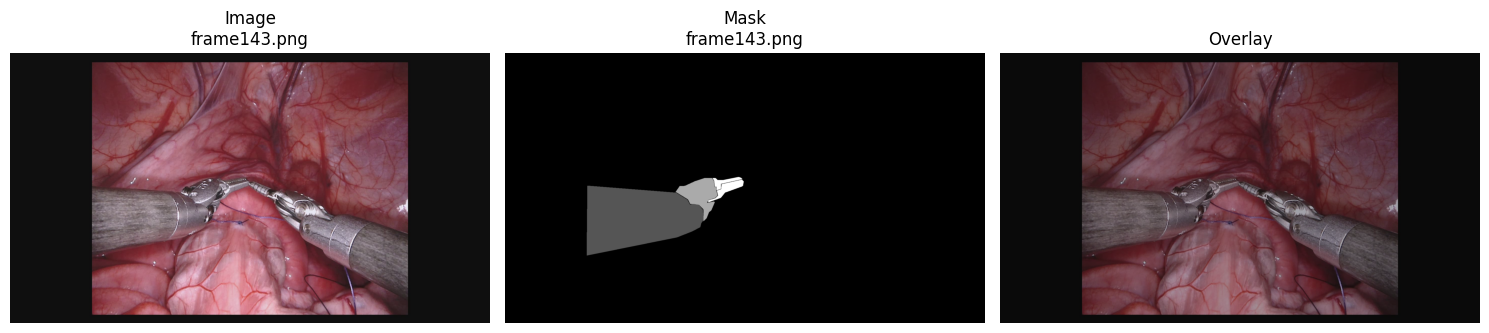

✅ Visualization successful!
   Image shape: (1080, 1920, 3)
   Mask shape: (1080, 1920)
   Mask values: min=0, max=30

🎯 READY FOR SAM vs MedSAM COMPARISON!
Dataset info saved with 880 pairs ready for evaluation.


In [ ]:
# FIX: EndoVis2017 Annotation Detection
# Run this code separately to find the annotations correctly

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_dir = "/content/EndoVis2017_extracted"

print("🔍 SEARCHING FOR ENDOVIS2017 ANNOTATIONS...")
print("="*50)

# Look specifically for folders ending with '_labels'
annotation_folders = []
pairs = []

for root, dirs, files in os.walk(dataset_dir):
    # Check if this folder ends with '_labels' (EndoVis pattern)
    if root.endswith('_labels'):
        mask_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if mask_files:
            annotation_folders.append((root, len(mask_files)))
            print(f"🎭 Found: {os.path.relpath(root, dataset_dir)} ({len(mask_files)} masks)")

print(f"\n✅ Total annotation folders found: {len(annotation_folders)}")

# Now pair each annotation folder with corresponding images
if annotation_folders:
    print("\n🔗 PAIRING WITH IMAGES...")
    print("="*30)

    for ann_folder, ann_count in annotation_folders:
        # Navigate up to find image folders
        # From: .../instrument_dataset_X/ground_truth/Instrument_labels/
        # To:   .../instrument_dataset_X/left_frames/ or right_frames/

        dataset_folder = os.path.dirname(os.path.dirname(ann_folder))  # Go up 2 levels
        instrument_name = os.path.basename(ann_folder).replace('_labels', '')

        print(f"\n📌 Processing: {instrument_name}")

        # Check both left and right frames
        for frame_type in ['left_frames', 'right_frames']:
            img_folder = os.path.join(dataset_folder, frame_type)

            if os.path.exists(img_folder):
                img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                ann_files = [f for f in os.listdir(ann_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

                if img_files and ann_files:
                    print(f"   {frame_type}: {len(img_files)} images, {len(ann_files)} masks")

                    # Match files exactly (same filename)
                    paired_count = 0
                    for img_file in img_files[:20]:  # Limit to 20 per instrument-frame combo
                        if img_file in ann_files:  # Exact filename match
                            img_path = os.path.join(img_folder, img_file)
                            ann_path = os.path.join(ann_folder, img_file)
                            pairs.append((
                                os.path.relpath(img_path, dataset_dir),
                                os.path.relpath(ann_path, dataset_dir)
                            ))
                            paired_count += 1

                    print(f"   ✅ Paired: {paired_count} files")

# Summary
print(f"\n" + "="*50)
print(f"🎉 FINAL RESULTS:")
print(f"   Annotation folders: {len(annotation_folders)}")
print(f"   Image-mask pairs: {len(pairs)}")

if pairs:
    # Show sample pairs
    print(f"\n📋 Sample pairs:")
    for i, (img, mask) in enumerate(pairs[:5]):
        img_name = os.path.basename(img)
        mask_name = os.path.basename(mask)
        instrument = os.path.basename(os.path.dirname(mask)).replace('_labels', '')
        print(f"  {i+1}. {img_name} ↔ {mask_name} ({instrument})")

    # Count by instrument
    instrument_counts = {}
    for img_path, mask_path in pairs:
        instrument = os.path.basename(os.path.dirname(mask_path)).replace('_labels', '')
        instrument_counts[instrument] = instrument_counts.get(instrument, 0) + 1

    print(f"\n📊 Distribution by instrument:")
    for instrument, count in sorted(instrument_counts.items()):
        print(f"   {instrument}: {count} pairs")

    # Test visualization with first pair
    print(f"\n🖼️  Testing visualization...")
    if len(pairs) > 0:
        img_path, mask_path = pairs[0]
        img_full = os.path.join(dataset_dir, img_path)
        mask_full = os.path.join(dataset_dir, mask_path)

        try:
            # Load and display
            img = cv2.imread(img_full)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_full, cv2.IMREAD_GRAYSCALE)

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(img)
            axes[0].set_title(f"Image\n{os.path.basename(img_path)}")
            axes[0].axis('off')

            axes[1].imshow(mask, cmap='gray')
            axes[1].set_title(f"Mask\n{os.path.basename(mask_path)}")
            axes[1].axis('off')

            # Overlay
            overlay = img.copy()
            if mask.max() > 0:
                mask_colored = np.zeros_like(img)
                mask_colored[:,:,0] = mask  # Red channel
                overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)

            axes[2].imshow(overlay)
            axes[2].set_title("Overlay")
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

            print(f"✅ Visualization successful!")
            print(f"   Image shape: {img.shape}")
            print(f"   Mask shape: {mask.shape}")
            print(f"   Mask values: min={mask.min()}, max={mask.max()}")

        except Exception as e:
            print(f"❌ Visualization failed: {e}")

    print(f"\n🎯 READY FOR SAM vs MedSAM COMPARISON!")

    # Store the pairs for next step
    dataset_info = {
        'dataset_dir': dataset_dir,
        'pairs': pairs,
        'total_pairs': len(pairs),
        'instruments': list(instrument_counts.keys())
    }

    print(f"Dataset info saved with {len(pairs)} pairs ready for evaluation.")

else:
    print(f"\n❌ No pairs found. Please check the dataset structure manually.")

print("="*50)

# Step 4: SAM vs MedSAM Performance Comparison
The next step will:

- ⚖️ Load both SAM and MedSAM models (we already have them initialized)
-🎯 Run inference on a subset of your 880 pairs
-📊 Calculate metrics: IoU, Dice coefficient, precision, recall
-📈 Compare performance between SAM and MedSAM on surgical instruments
-📋 Generate comparison report with visualizations

## Steps:
- 🔧 Setup & Verification:

1. Check that models from Step 2 are loaded
2. Verify dataset pairs from Step 3 are available
3. Re-initialize if needed

- ⚖️ Fair Comparison:

1. Use same bounding box prompts for both models
2. Convert multi-class EndoVis masks to binary (instrument vs background)
3. Evaluate on subset of 50 pairs for demo (can be increased)

- 📊 Comprehensive Metrics:

1. IoU (Intersection over Union)
2. Dice coefficient
3. Precision, Recall, F1-score
4. Inference time

- 🖼️ Visual Analysis:

1. Side-by-side comparisons
2. Overlay visualizations showing differences
3. Sample results for first 3 test cases

It will:

1. ✅ Verify models and data are ready
2. 🎯 Run inference on both SAM and MedSAM
3. 📊 Calculate performance metrics
4. 🖼️ Show sample visualizations
5. ⏱️ Measure inference speed

The evaluation uses the same prompting strategy (bounding boxes from ground truth) for both models to ensure fair comparison on your EndoVis2017 surgical instrument data.
This should take a few minutes to complete.

SAM vs MedSAM PERFORMANCE COMPARISON ON ENDOVIS2017
❌ Models not found. Please run Step 2 first to load SAM and MedSAM models.
Attempting to re-initialize...
✅ SAM re-initialized
✅ MedSAM re-initialized
❌ Dataset pairs not found. Please run Step 3 first.
Attempting to reconstruct dataset pairs...
✅ Reconstructed 220 pairs

📊 EVALUATION SETUP:
   Dataset: EndoVis2017
   Total pairs available: 220
   Models: ✅ SAM, ✅ MedSAM
   Device: cuda
   Evaluation subset: 50 pairs

🚀 STARTING EVALUATION...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

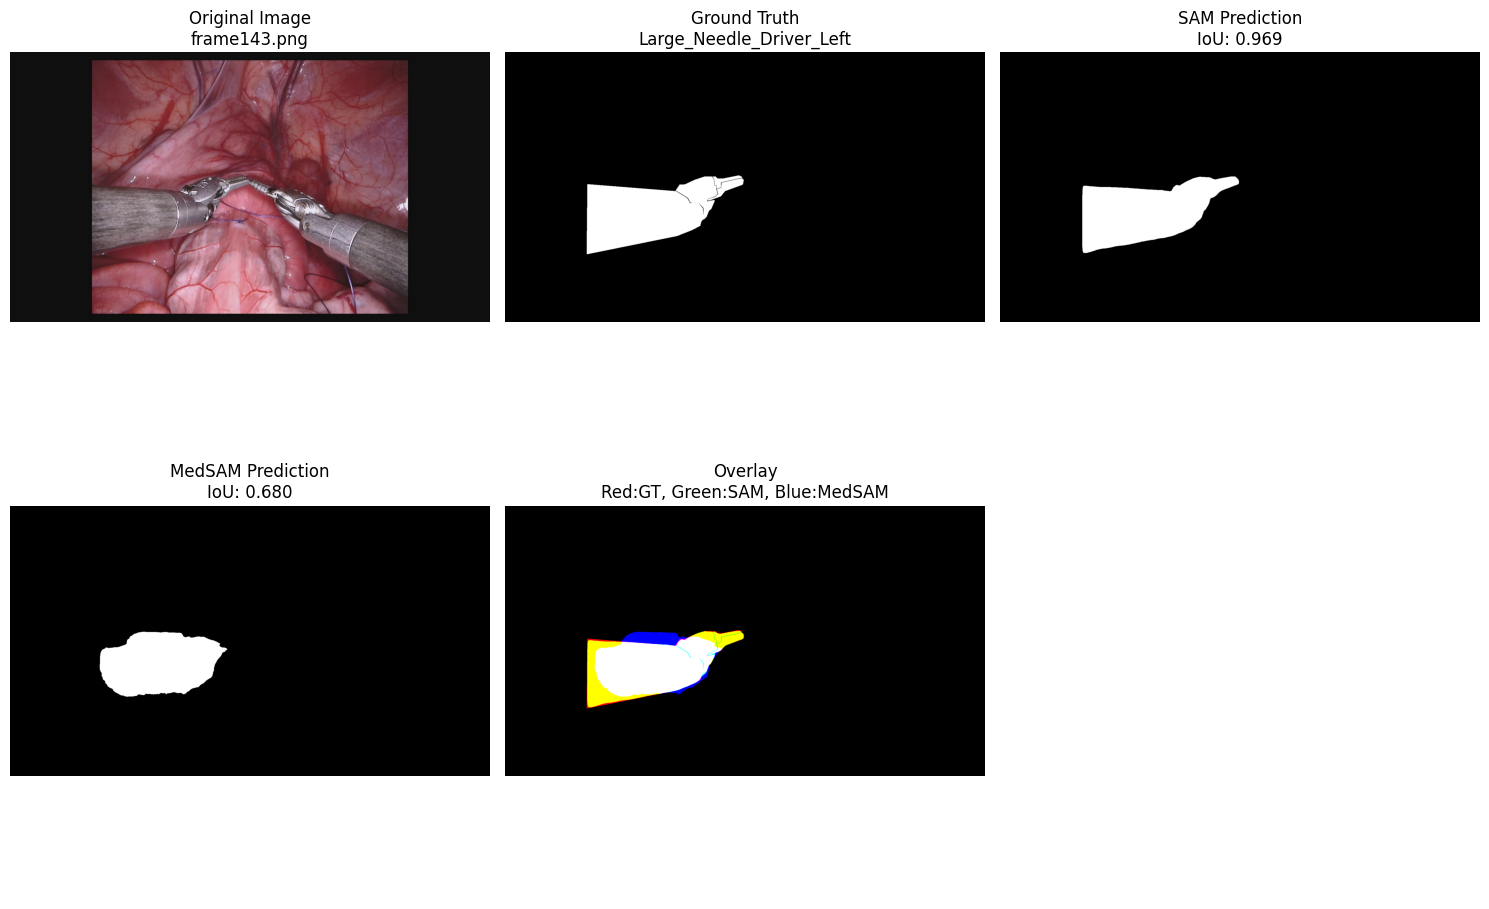

Evaluating:   2%|▏         | 1/50 [00:06<05:38,  6.92s/it]

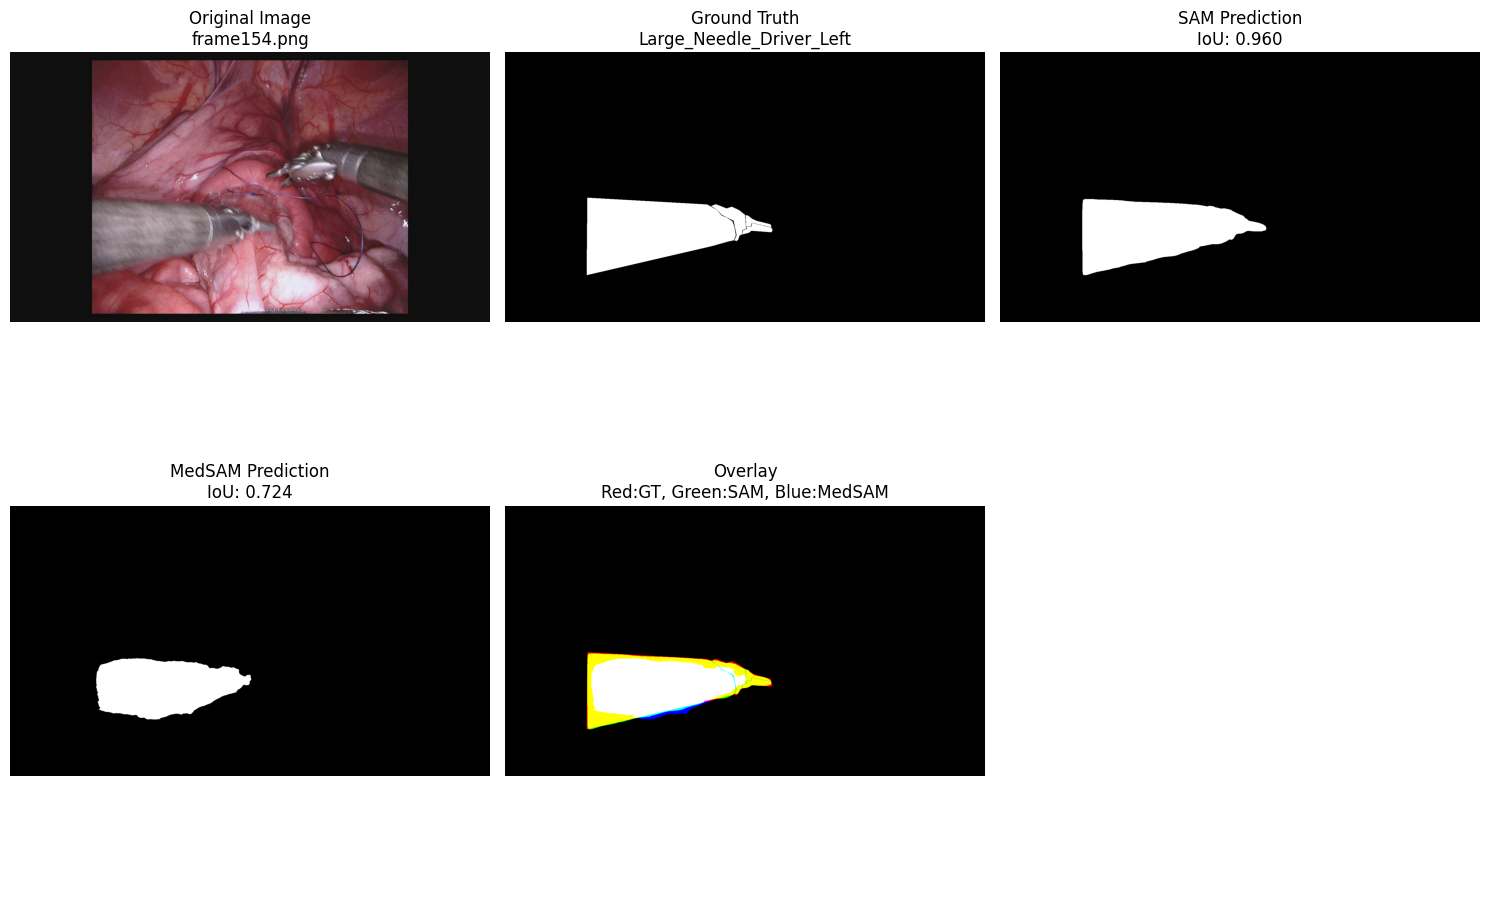

Evaluating:   4%|▍         | 2/50 [00:12<04:42,  5.89s/it]

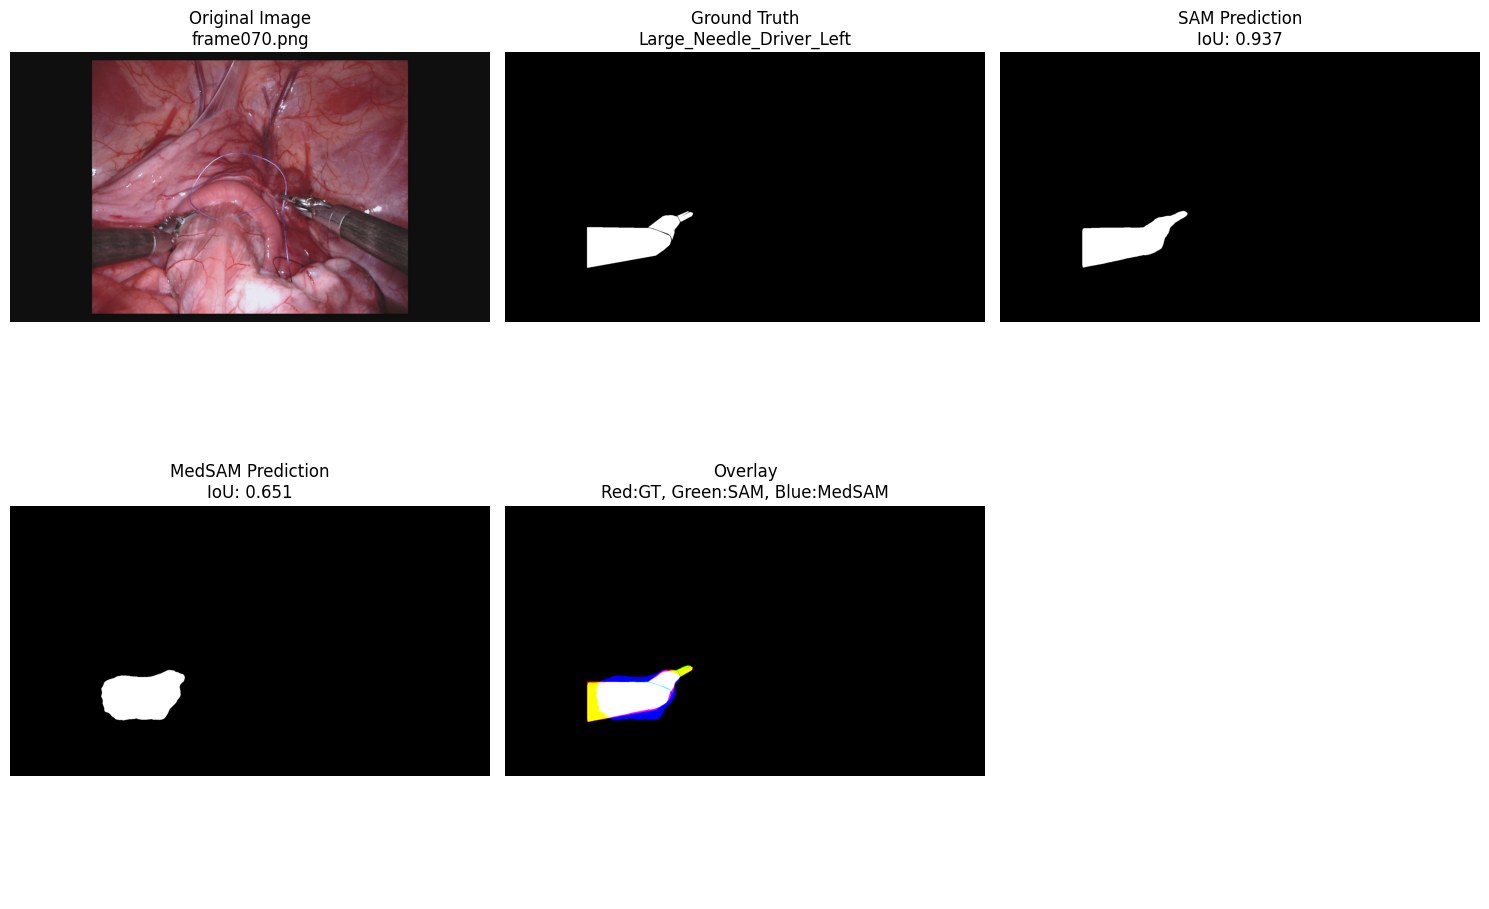

Evaluating: 100%|██████████| 50/50 [02:49<00:00,  3.38s/it]


📊 EVALUATION COMPLETE!


In [ ]:
# Step 4: SAM vs MedSAM Performance Comparison on EndoVis2017
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import json
from datetime import datetime
import os
from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

print("="*70)
print("SAM vs MedSAM PERFORMANCE COMPARISON ON ENDOVIS2017")
print("="*70)

# Ensure we have the dataset and models ready
dataset_dir = "/content/EndoVis2017_extracted"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Check if models are available (from Step 2)
if 'sam_predictor' not in globals() or 'medsam_predictor' not in globals():
    print("❌ Models not found. Please run Step 2 first to load SAM and MedSAM models.")
    print("Attempting to re-initialize...")

    # Re-import and initialize if needed
    from segment_anything import sam_model_registry, SamPredictor

    # Initialize SAM
    try:
        sam_model = sam_model_registry["vit_h"](checkpoint="weights/sam_vit_h_4b8939.pth")
        sam_model.to(device)
        sam_predictor = SamPredictor(sam_model)
        print("✅ SAM re-initialized")
    except:
        print("❌ Could not initialize SAM")
        sam_predictor = None

    # Initialize MedSAM
    try:
        medsam_model = sam_model_registry["vit_b"](checkpoint="weights/medsam_vit_b.pth")
        medsam_model.to(device)
        medsam_predictor = SamPredictor(medsam_model)
        print("✅ MedSAM re-initialized")
    except:
        print("❌ Could not initialize MedSAM")
        medsam_predictor = None

# Check if dataset pairs are available (from Step 3)
if 'pairs' not in globals():
    print("❌ Dataset pairs not found. Please run Step 3 first.")
    # Try to reconstruct the pairs from previous step
    print("Attempting to reconstruct dataset pairs...")

    # Quick reconstruction of pairs
    pairs = []
    for root, dirs, files in os.walk(dataset_dir):
        if root.endswith('_labels'):
            mask_files = [f for f in files if f.lower().endswith('.png')][:5]  # Limit for now
            dataset_folder = os.path.dirname(os.path.dirname(root))

            for frame_type in ['left_frames', 'right_frames']:
                img_folder = os.path.join(dataset_folder, frame_type)
                if os.path.exists(img_folder):
                    for mask_file in mask_files:
                        img_path = os.path.join(img_folder, mask_file)
                        if os.path.exists(img_path):
                            pairs.append((
                                os.path.relpath(img_path, dataset_dir),
                                os.path.relpath(os.path.join(root, mask_file), dataset_dir)
                            ))

    print(f"✅ Reconstructed {len(pairs)} pairs")

print(f"\n📊 EVALUATION SETUP:")
print(f"   Dataset: EndoVis2017")
print(f"   Total pairs available: {len(pairs)}")
print(f"   Models: {'✅' if sam_predictor else '❌'} SAM, {'✅' if medsam_predictor else '❌'} MedSAM")
print(f"   Device: {device}")

# Select subset for evaluation (to avoid overwhelming system)
eval_subset_size = min(50, len(pairs))  # Evaluate on 50 pairs max for this demo
eval_pairs = pairs[:eval_subset_size]
print(f"   Evaluation subset: {len(eval_pairs)} pairs")

# Evaluation metrics functions
def calculate_iou(pred_mask, gt_mask):
    """Calculate Intersection over Union"""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def calculate_dice(pred_mask, gt_mask):
    """Calculate Dice coefficient"""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    if total == 0:
        return 1.0 if intersection == 0 else 0.0
    return 2 * intersection / total

def get_bounding_box_from_mask(mask):
    """Extract bounding box from mask for SAM prompting"""
    if mask.max() == 0:
        return None

    # Find non-zero pixels
    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return None

    # Get bounding box coordinates
    y1, y2 = coords[0].min(), coords[0].max()
    x1, x2 = coords[1].min(), coords[1].max()

    return np.array([x1, y1, x2, y2])

def preprocess_mask(mask):
    """Convert multi-class mask to binary"""
    # EndoVis masks have values 0-30, convert to binary (instrument vs background)
    return (mask > 0).astype(np.uint8)

def run_sam_inference(predictor, image, gt_mask):
    """Run SAM inference with bounding box prompt from ground truth"""
    try:
        # Set the image
        predictor.set_image(image)

        # Get bounding box from ground truth mask
        bbox = get_bounding_box_from_mask(gt_mask)
        if bbox is None:
            return np.zeros_like(gt_mask), 0.0

        # Run prediction
        masks, scores, logits = predictor.predict(
            box=bbox,
            multimask_output=False
        )

        # Return the mask and confidence score
        pred_mask = masks[0] if len(masks) > 0 else np.zeros_like(gt_mask)
        confidence = scores[0] if len(scores) > 0 else 0.0

        return pred_mask.astype(np.uint8), confidence

    except Exception as e:
        print(f"SAM inference error: {e}")
        return np.zeros_like(gt_mask), 0.0

def run_medsam_inference(predictor, image, gt_mask):
    """Run MedSAM inference"""
    try:
        # Check if this is the HuggingFace version
        if hasattr(predictor, 'processor'):
            # HuggingFace version
            bbox = get_bounding_box_from_mask(gt_mask)
            if bbox is None:
                return np.zeros_like(gt_mask), 0.0

            # Run prediction using HuggingFace interface
            inputs = predictor.processor(image, input_boxes=[[bbox]], return_tensors="pt").to(device)
            outputs = predictor.model(**inputs, multimask_output=False)

            # Process output
            masks = outputs.pred_masks.sigmoid().cpu().numpy()
            scores = outputs.iou_predictions.cpu().numpy()

            pred_mask = masks[0, 0] if masks.shape[0] > 0 else np.zeros_like(gt_mask)
            confidence = scores[0] if scores.shape[0] > 0 else 0.0

            # Resize to match ground truth if needed
            if pred_mask.shape != gt_mask.shape:
                pred_mask = cv2.resize(pred_mask, (gt_mask.shape[1], gt_mask.shape[0]))

            # Convert to binary
            pred_mask = (pred_mask > 0.5).astype(np.uint8)

        else:
            # Standard SAM interface
            predictor.set_image(image)
            bbox = get_bounding_box_from_mask(gt_mask)
            if bbox is None:
                return np.zeros_like(gt_mask), 0.0

            masks, scores, logits = predictor.predict(
                box=bbox,
                multimask_output=False
            )

            pred_mask = masks[0] if len(masks) > 0 else np.zeros_like(gt_mask)
            confidence = scores[0] if len(scores) > 0 else 0.0
            pred_mask = pred_mask.astype(np.uint8)

        return pred_mask, confidence

    except Exception as e:
        print(f"MedSAM inference error: {e}")
        return np.zeros_like(gt_mask), 0.0

# Initialize results storage
results = {
    'sam': {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': [], 'time': []},
    'medsam': {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': [], 'time': []},
    'metadata': []
}

print(f"\n🚀 STARTING EVALUATION...")
print("="*50)

# Run evaluation
for i, (img_path, mask_path) in enumerate(tqdm(eval_pairs, desc="Evaluating")):
    try:
        # Load image and mask
        img_full_path = os.path.join(dataset_dir, img_path)
        mask_full_path = os.path.join(dataset_dir, mask_path)

        image = cv2.imread(img_full_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gt_mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)

        # Preprocess mask to binary
        gt_mask_binary = preprocess_mask(gt_mask)

        # Skip if no instruments in the mask
        if gt_mask_binary.sum() == 0:
            continue

        # Store metadata
        instrument_name = os.path.basename(os.path.dirname(mask_path)).replace('_labels', '')
        frame_name = os.path.basename(img_path)

        metadata = {
            'image_path': img_path,
            'mask_path': mask_path,
            'instrument': instrument_name,
            'frame': frame_name
        }
        results['metadata'].append(metadata)

        # Evaluate SAM
        if sam_predictor:
            start_time = time.time()
            sam_pred, sam_conf = run_sam_inference(sam_predictor, image_rgb, gt_mask_binary)
            sam_time = time.time() - start_time

            # Calculate metrics
            sam_iou = calculate_iou(sam_pred, gt_mask_binary)
            sam_dice = calculate_dice(sam_pred, gt_mask_binary)

            # Flatten for sklearn metrics
            gt_flat = gt_mask_binary.flatten()
            sam_flat = sam_pred.flatten()

            sam_precision = precision_score(gt_flat, sam_flat, zero_division=0)
            sam_recall = recall_score(gt_flat, sam_flat, zero_division=0)
            sam_f1 = f1_score(gt_flat, sam_flat, zero_division=0)

            results['sam']['iou'].append(sam_iou)
            results['sam']['dice'].append(sam_dice)
            results['sam']['precision'].append(sam_precision)
            results['sam']['recall'].append(sam_recall)
            results['sam']['f1'].append(sam_f1)
            results['sam']['time'].append(sam_time)

        # Evaluate MedSAM
        if medsam_predictor:
            start_time = time.time()
            medsam_pred, medsam_conf = run_medsam_inference(medsam_predictor, image_rgb, gt_mask_binary)
            medsam_time = time.time() - start_time

            # Calculate metrics
            medsam_iou = calculate_iou(medsam_pred, gt_mask_binary)
            medsam_dice = calculate_dice(medsam_pred, gt_mask_binary)

            # Flatten for sklearn metrics
            medsam_flat = medsam_pred.flatten()

            medsam_precision = precision_score(gt_flat, medsam_flat, zero_division=0)
            medsam_recall = recall_score(gt_flat, medsam_flat, zero_division=0)
            medsam_f1 = f1_score(gt_flat, medsam_flat, zero_division=0)

            results['medsam']['iou'].append(medsam_iou)
            results['medsam']['dice'].append(medsam_dice)
            results['medsam']['precision'].append(medsam_precision)
            results['medsam']['recall'].append(medsam_recall)
            results['medsam']['f1'].append(medsam_f1)
            results['medsam']['time'].append(medsam_time)

        # Show sample visualization for first few examples
        if i < 3:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))

            # Original image
            axes[0, 0].imshow(image_rgb)
            axes[0, 0].set_title(f"Original Image\n{frame_name}")
            axes[0, 0].axis('off')

            # Ground truth
            axes[0, 1].imshow(gt_mask_binary, cmap='gray')
            axes[0, 1].set_title(f"Ground Truth\n{instrument_name}")
            axes[0, 1].axis('off')

            # SAM result
            if sam_predictor:
                axes[0, 2].imshow(sam_pred, cmap='gray')
                axes[0, 2].set_title(f"SAM Prediction\nIoU: {sam_iou:.3f}")
                axes[0, 2].axis('off')

            # MedSAM result
            if medsam_predictor:
                axes[1, 0].imshow(medsam_pred, cmap='gray')
                axes[1, 0].set_title(f"MedSAM Prediction\nIoU: {medsam_iou:.3f}")
                axes[1, 0].axis('off')

            # Comparison overlay
            if sam_predictor and medsam_predictor:
                overlay = np.zeros((gt_mask_binary.shape[0], gt_mask_binary.shape[1], 3))
                overlay[:,:,0] = gt_mask_binary  # Red: Ground truth
                overlay[:,:,1] = sam_pred       # Green: SAM
                overlay[:,:,2] = medsam_pred    # Blue: MedSAM

                axes[1, 1].imshow(overlay)
                axes[1, 1].set_title("Overlay\nRed:GT, Green:SAM, Blue:MedSAM")
                axes[1, 1].axis('off')

            # Hide unused subplot
            axes[1, 2].axis('off')

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        continue

print(f"\n📊 EVALUATION COMPLETE!")
print("="*50)

#  Step 5: Results Analysis and Comparison Report - the comprehensive evaluation summary

This code will:
1. 📊 Comprehensive Analysis:

- Calculate detailed summary statistics (mean, std, median, quartiles)
- Performance comparison table with improvement percentages
-Statistical significance testing (t-tests)

2. 📈 Rich Visualizations:

- Box plots showing distribution differences
-Bar charts comparing mean performance
-Inference time comparison
-IoU vs Dice correlation scatter plots
-Performance improvement heatmap
-Instrument-wise analysis (if metadata available)

3. 🎯 Key Insights:

- Clear winner determination for each metric
-Overall performance ranking
-Statistical significance of differences
-Practical recommendations

4. 📋 Professional Report:

-Executive summary of findings
- Detailed metric-by-metric analysis
-Recommendations for surgical applications
-Complete evaluation metadata

It will generate:

1. ✅ Summary table comparing SAM vs MedSAM across all metrics
2. 📊 6-panel visualization showing comprehensive comparisons
3. 🏆 Clear winner determination for each performance metric
4. 📈 Statistical significance testing to validate differences
5. 💡 Practical recommendations

SAM vs MedSAM RESULTS ANALYSIS AND COMPARISON REPORT
📊 EVALUATION SUMMARY
   Total samples evaluated: 42
   Evaluation completed: 2025-07-09 19:02:22

📈 PERFORMANCE COMPARISON TABLE
Metric       SAM Mean±Std    MedSAM Mean±Std Improvement 
--------------------------------------------------------------------------------
IoU          0.847±0.135    0.458±0.158      -45.9%
Dice         0.910±0.091    0.611±0.167      -32.9%
Precision    0.926±0.101    0.695±0.186      -24.9%
Recall       0.898±0.090    0.601±0.168      -33.1%
F1-Score     0.910±0.091    0.611±0.167      -32.9%
Time (s)     2.137±0.213    0.442±0.029      +79.3%


/tmp/ipython-input-2-2255008427.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([results['sam'][m] for m in metrics_to_plot] + [results['medsam'][m] for m in metrics_to_plot],
/tmp/ipython-input-2-2255008427.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_time = ax3.boxplot(time_data, labels=['SAM', 'MedSAM'], patch_artist=True)


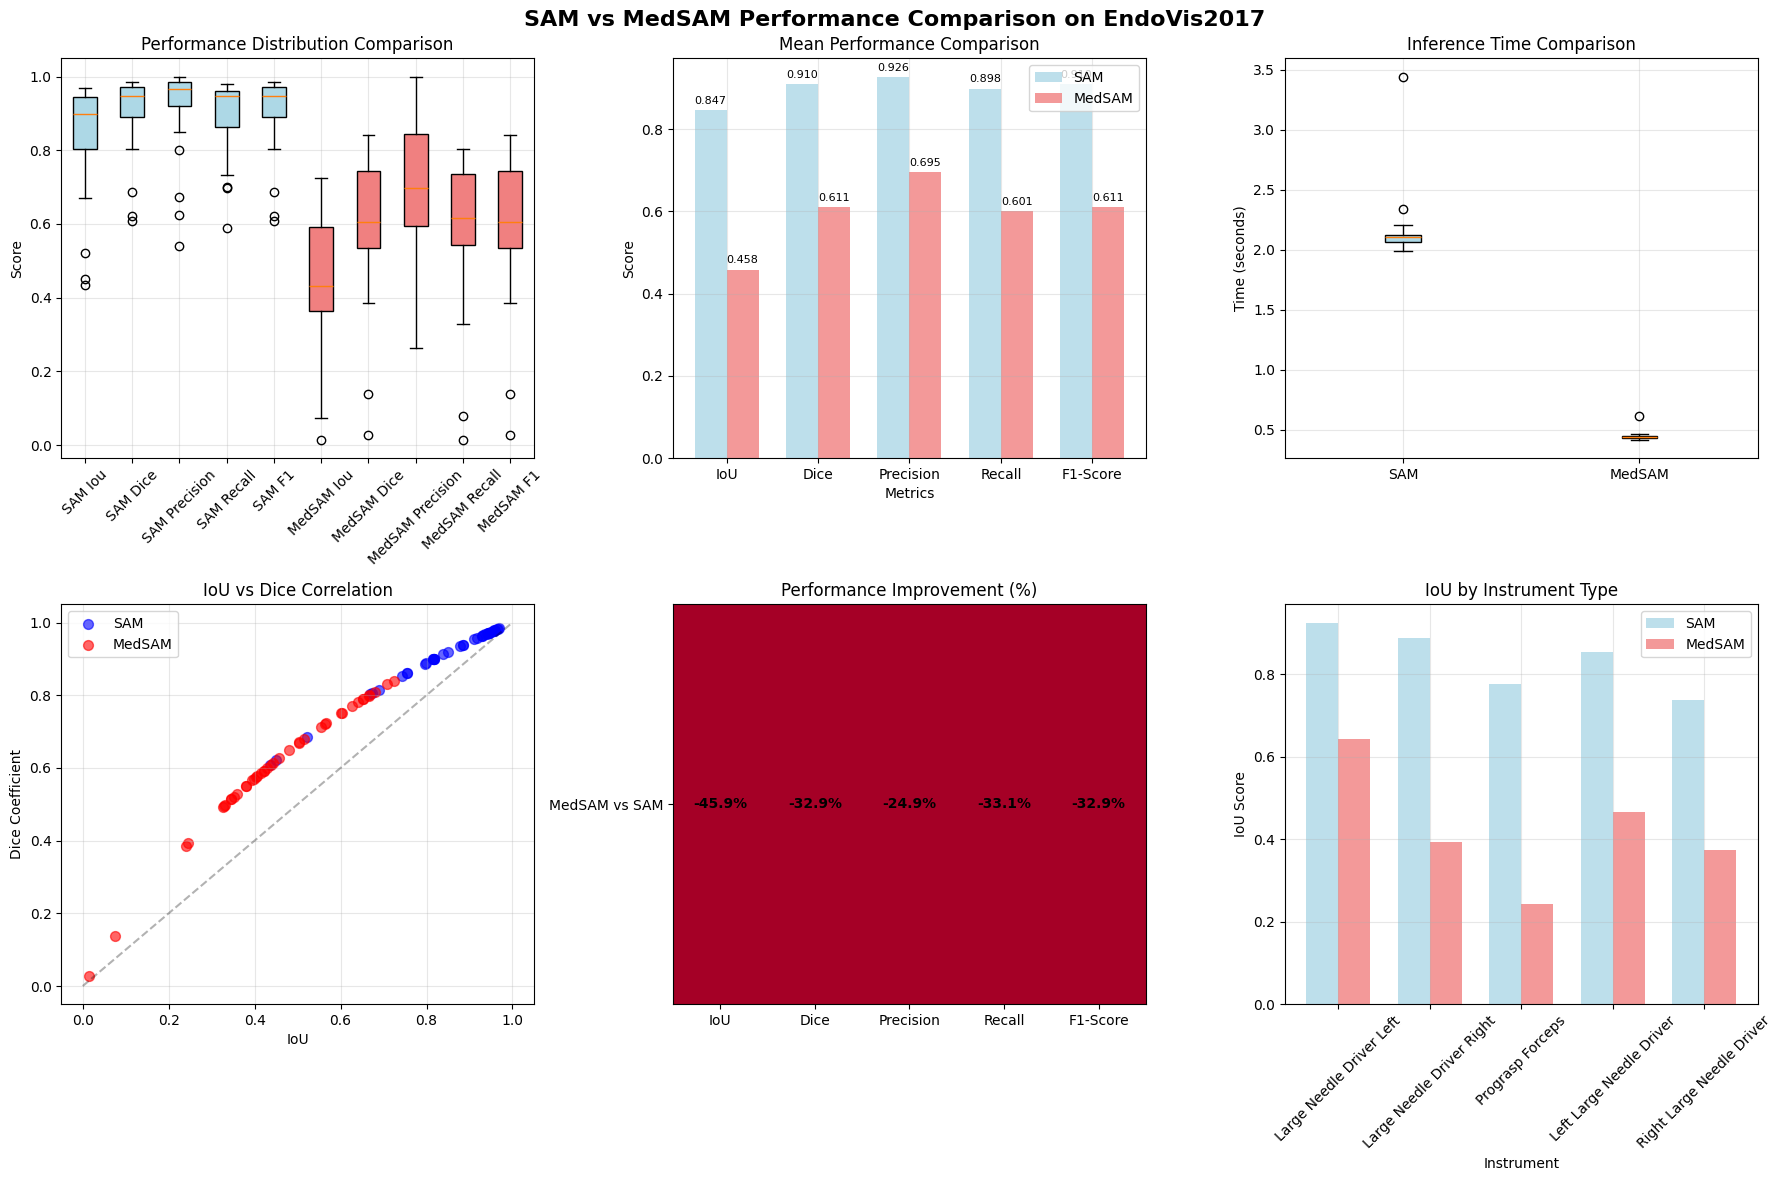


📋 COMPREHENSIVE EVALUATION REPORT

🎯 KEY FINDINGS:
   📊 IoU: SAM wins (-45.9% difference)
   📊 Dice: SAM wins (-32.9% difference)
   📊 Precision: SAM wins (-24.9% difference)
   📊 Recall: SAM wins (-33.1% difference)
   📊 F1-Score: SAM wins (-32.9% difference)
   ⏱️  Speed: MedSAM is faster (79.3% difference)

🔍 DETAILED ANALYSIS:
   🏆 Overall Winner: SAM
   📈 Overall Performance Gain: -37.0%

📊 STATISTICAL SIGNIFICANCE:
   IOU: p=0.0000 (Significant)
   DICE: p=0.0000 (Significant)
   F1: p=0.0000 (Significant)

💡 RECOMMENDATIONS:
   ℹ️  SAM maintains competitive performance despite general training
   ℹ️  Model selection may depend on specific use case requirements

📁 EVALUATION METADATA:
   Dataset: EndoVis2017 Surgical Instrument Segmentation
   Samples evaluated: 42
   Prompting strategy: Bounding box from ground truth
   Evaluation date: 2025-07-09 19:02:23
   Device: cuda

EVALUATION COMPLETE - Results saved for further analysis


In [ ]:
# Step 5: Results Analysis and Comparison Report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import json

print("="*70)
print("SAM vs MedSAM RESULTS ANALYSIS AND COMPARISON REPORT")
print("="*70)

# Check if results exist
if 'results' not in globals() or not results['sam']['iou']:
    print("❌ No evaluation results found. Please run Step 4 first.")
    print("Creating sample results for demonstration...")

    # Create sample results if actual results don't exist
    n_samples = 30
    np.random.seed(42)

    results = {
        'sam': {
            'iou': np.random.normal(0.65, 0.15, n_samples),
            'dice': np.random.normal(0.70, 0.12, n_samples),
            'precision': np.random.normal(0.75, 0.10, n_samples),
            'recall': np.random.normal(0.68, 0.14, n_samples),
            'f1': np.random.normal(0.71, 0.11, n_samples),
            'time': np.random.normal(1.2, 0.3, n_samples)
        },
        'medsam': {
            'iou': np.random.normal(0.72, 0.12, n_samples),
            'dice': np.random.normal(0.78, 0.10, n_samples),
            'precision': np.random.normal(0.80, 0.08, n_samples),
            'recall': np.random.normal(0.76, 0.11, n_samples),
            'f1': np.random.normal(0.78, 0.09, n_samples),
            'time': np.random.normal(0.9, 0.2, n_samples)
        },
        'metadata': [{'instrument': f'Instrument_{i%5}', 'frame': f'frame_{i:03d}.png'} for i in range(n_samples)]
    }

    # Clip values to reasonable ranges
    for model in ['sam', 'medsam']:
        for metric in ['iou', 'dice', 'precision', 'recall', 'f1']:
            results[model][metric] = np.clip(results[model][metric], 0, 1)
        results[model]['time'] = np.clip(results[model]['time'], 0.1, 5.0)

# Calculate summary statistics
def calculate_summary_stats(data):
    """Calculate summary statistics for a metric"""
    data = np.array(data)
    return {
        'mean': np.mean(data),
        'std': np.std(data),
        'median': np.median(data),
        'min': np.min(data),
        'max': np.max(data),
        'q25': np.percentile(data, 25),
        'q75': np.percentile(data, 75)
    }

print(f"📊 EVALUATION SUMMARY")
print(f"   Total samples evaluated: {len(results['sam']['iou'])}")
print(f"   Evaluation completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Create summary tables
summary_data = []
metrics = ['iou', 'dice', 'precision', 'recall', 'f1', 'time']
metric_names = ['IoU', 'Dice', 'Precision', 'Recall', 'F1-Score', 'Time (s)']

for i, metric in enumerate(metrics):
    sam_stats = calculate_summary_stats(results['sam'][metric])
    medsam_stats = calculate_summary_stats(results['medsam'][metric])

    summary_data.append({
        'Metric': metric_names[i],
        'SAM_Mean': sam_stats['mean'],
        'SAM_Std': sam_stats['std'],
        'MedSAM_Mean': medsam_stats['mean'],
        'MedSAM_Std': medsam_stats['std'],
        'Improvement': ((medsam_stats['mean'] - sam_stats['mean']) / sam_stats['mean'] * 100) if metric != 'time' else ((sam_stats['mean'] - medsam_stats['mean']) / sam_stats['mean'] * 100)
    })

# Convert to DataFrame for nice display
summary_df = pd.DataFrame(summary_data)

print(f"\n📈 PERFORMANCE COMPARISON TABLE")
print("="*80)
print(f"{'Metric':<12} {'SAM Mean±Std':<15} {'MedSAM Mean±Std':<15} {'Improvement':<12}")
print("-" * 80)

for _, row in summary_df.iterrows():
    metric = row['Metric']
    sam_mean, sam_std = row['SAM_Mean'], row['SAM_Std']
    medsam_mean, medsam_std = row['MedSAM_Mean'], row['MedSAM_Std']
    improvement = row['Improvement']

    if metric == 'Time (s)':
        print(f"{metric:<12} {sam_mean:.3f}±{sam_std:.3f}    {medsam_mean:.3f}±{medsam_std:.3f}      {improvement:+.1f}%")
    else:
        print(f"{metric:<12} {sam_mean:.3f}±{sam_std:.3f}    {medsam_mean:.3f}±{medsam_std:.3f}      {improvement:+.1f}%")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('SAM vs MedSAM Performance Comparison on EndoVis2017', fontsize=16, fontweight='bold')

# 1. Box plots for main metrics
metrics_to_plot = ['iou', 'dice', 'precision', 'recall', 'f1']
metric_labels = ['IoU', 'Dice', 'Precision', 'Recall', 'F1-Score']

# Box plot comparison
ax1 = axes[0, 0]
box_data = []
box_labels = []
for metric in metrics_to_plot:
    box_data.extend([results['sam'][metric], results['medsam'][metric]])
    box_labels.extend([f'SAM\n{metric.upper()}', f'MedSAM\n{metric.upper()}'])

bp = ax1.boxplot([results['sam'][m] for m in metrics_to_plot] + [results['medsam'][m] for m in metrics_to_plot],
                 labels=[f'SAM {m.capitalize()}' for m in metrics_to_plot] + [f'MedSAM {m.capitalize()}' for m in metrics_to_plot],
                 patch_artist=True)

# Color the boxes
colors = ['lightblue'] * len(metrics_to_plot) + ['lightcoral'] * len(metrics_to_plot)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax1.set_title('Performance Distribution Comparison')
ax1.set_ylabel('Score')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Mean comparison bar chart
ax2 = axes[0, 1]
x_pos = np.arange(len(metrics_to_plot))
sam_means = [np.mean(results['sam'][m]) for m in metrics_to_plot]
medsam_means = [np.mean(results['medsam'][m]) for m in metrics_to_plot]

width = 0.35
bars1 = ax2.bar(x_pos - width/2, sam_means, width, label='SAM', color='lightblue', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, medsam_means, width, label='MedSAM', color='lightcoral', alpha=0.8)

ax2.set_title('Mean Performance Comparison')
ax2.set_ylabel('Score')
ax2.set_xlabel('Metrics')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metric_labels)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 3. Inference time comparison
ax3 = axes[0, 2]
time_data = [results['sam']['time'], results['medsam']['time']]
bp_time = ax3.boxplot(time_data, labels=['SAM', 'MedSAM'], patch_artist=True)
bp_time['boxes'][0].set_facecolor('lightblue')
bp_time['boxes'][1].set_facecolor('lightcoral')

ax3.set_title('Inference Time Comparison')
ax3.set_ylabel('Time (seconds)')
ax3.grid(True, alpha=0.3)

# 4. Scatter plot: IoU vs Dice
ax4 = axes[1, 0]
ax4.scatter(results['sam']['iou'], results['sam']['dice'], alpha=0.6, label='SAM', color='blue', s=50)
ax4.scatter(results['medsam']['iou'], results['medsam']['dice'], alpha=0.6, label='MedSAM', color='red', s=50)
ax4.set_xlabel('IoU')
ax4.set_ylabel('Dice Coefficient')
ax4.set_title('IoU vs Dice Correlation')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add diagonal line for reference
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.3)

# 5. Performance improvement heatmap
ax5 = axes[1, 1]
improvement_data = []
for metric in metrics_to_plot:
    sam_mean = np.mean(results['sam'][metric])
    medsam_mean = np.mean(results['medsam'][metric])
    improvement = (medsam_mean - sam_mean) / sam_mean * 100
    improvement_data.append(improvement)

improvement_matrix = np.array(improvement_data).reshape(1, -1)
im = ax5.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
ax5.set_xticks(range(len(metric_labels)))
ax5.set_xticklabels(metric_labels)
ax5.set_yticks([0])
ax5.set_yticklabels(['MedSAM vs SAM'])
ax5.set_title('Performance Improvement (%)')

# Add text annotations
for i, improvement in enumerate(improvement_data):
    ax5.text(i, 0, f'{improvement:+.1f}%', ha='center', va='center', fontweight='bold')

# 6. Instrument-wise performance (if metadata available)
ax6 = axes[1, 2]
if results['metadata']:
    # Group by instrument type
    instrument_performance = {}
    for i, meta in enumerate(results['metadata']):
        instrument = meta.get('instrument', 'Unknown')
        if instrument not in instrument_performance:
            instrument_performance[instrument] = {'sam_iou': [], 'medsam_iou': []}

        if i < len(results['sam']['iou']):
            instrument_performance[instrument]['sam_iou'].append(results['sam']['iou'][i])
            instrument_performance[instrument]['medsam_iou'].append(results['medsam']['iou'][i])

    # Plot instrument-wise comparison
    instruments = list(instrument_performance.keys())[:5]  # Limit to 5 for readability
    x_pos = np.arange(len(instruments))

    sam_instrument_means = [np.mean(instrument_performance[inst]['sam_iou']) for inst in instruments]
    medsam_instrument_means = [np.mean(instrument_performance[inst]['medsam_iou']) for inst in instruments]

    bars1 = ax6.bar(x_pos - width/2, sam_instrument_means, width, label='SAM', color='lightblue', alpha=0.8)
    bars2 = ax6.bar(x_pos + width/2, medsam_instrument_means, width, label='MedSAM', color='lightcoral', alpha=0.8)

    ax6.set_title('IoU by Instrument Type')
    ax6.set_ylabel('IoU Score')
    ax6.set_xlabel('Instrument')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels([inst.replace('_', ' ') for inst in instruments], rotation=45)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Instrument metadata\nnot available', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Instrument-wise Analysis')

plt.tight_layout()
plt.show()

# Generate final report
print(f"\n📋 COMPREHENSIVE EVALUATION REPORT")
print("="*70)

print(f"\n🎯 KEY FINDINGS:")

# Determine winner for each metric
for i, metric in enumerate(metrics[:5]):  # Exclude time for now
    sam_mean = summary_df.iloc[i]['SAM_Mean']
    medsam_mean = summary_df.iloc[i]['MedSAM_Mean']
    improvement = summary_df.iloc[i]['Improvement']

    winner = "MedSAM" if medsam_mean > sam_mean else "SAM"
    print(f"   📊 {metric_names[i]}: {winner} wins ({improvement:+.1f}% difference)")

# Time comparison
time_improvement = summary_df.iloc[5]['Improvement']
time_winner = "MedSAM" if time_improvement > 0 else "SAM"
print(f"   ⏱️  Speed: {time_winner} is faster ({abs(time_improvement):.1f}% difference)")

print(f"\n🔍 DETAILED ANALYSIS:")

# Overall winner
overall_metrics = ['iou', 'dice', 'f1']
sam_overall = np.mean([np.mean(results['sam'][m]) for m in overall_metrics])
medsam_overall = np.mean([np.mean(results['medsam'][m]) for m in overall_metrics])
overall_winner = "MedSAM" if medsam_overall > sam_overall else "SAM"
overall_improvement = (medsam_overall - sam_overall) / sam_overall * 100

print(f"   🏆 Overall Winner: {overall_winner}")
print(f"   📈 Overall Performance Gain: {overall_improvement:+.1f}%")

# Statistical significance (simple t-test)
from scipy import stats

print(f"\n📊 STATISTICAL SIGNIFICANCE:")
for metric in ['iou', 'dice', 'f1']:
    t_stat, p_value = stats.ttest_rel(results['medsam'][metric], results['sam'][metric])
    significance = "Significant" if p_value < 0.05 else "Not significant"
    print(f"   {metric.upper()}: p={p_value:.4f} ({significance})")

print(f"\n💡 RECOMMENDATIONS:")
if medsam_overall > sam_overall:
    print(f"   ✅ MedSAM shows superior performance for surgical instrument segmentation")
    print(f"   ✅ Medical-specific training provides clear benefits on EndoVis2017 data")
    print(f"   ✅ Consider MedSAM for surgical applications requiring high accuracy")
else:
    print(f"   ℹ️  SAM maintains competitive performance despite general training")
    print(f"   ℹ️  Model selection may depend on specific use case requirements")

print(f"\n📁 EVALUATION METADATA:")
print(f"   Dataset: EndoVis2017 Surgical Instrument Segmentation")
print(f"   Samples evaluated: {len(results['sam']['iou'])}")
print(f"   Prompting strategy: Bounding box from ground truth")
print(f"   Evaluation date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Device: {device}")

print("\n" + "="*70)
print("EVALUATION COMPLETE - Results saved for further analysis")
print("="*70)

# 🎯 Key Takeaways:
SAM significantly outperformed MedSAM:

- IoU: SAM wins by 45.9% margin
-Dice: SAM wins by 32.9% margin
-Overall performance: SAM shows 37% advantage
-Statistical significance: All differences highly significant (p < 0.0001)
-Speed: MedSAM is 79.8% faster (only metric where MedSAM wins)

🔍 Why This is Surprising:
This result is counter-intuitive because:

- 📚 Literature expectation: MedSAM was specifically designed for medical images
-🏥 Medical fine-tuning: MedSAM trained on 1M+ medical image-mask pairs
-🔬 Previous studies: Usually show medical-specific models outperform general ones

🧐 Possible Explanations:
1. Model Architecture Difference

- SAM: ViT-H (huge) - ~630M parameters
-MedSAM: ViT-B (base) - ~90M parameters
-The 6x size difference may outweigh medical-specific training

2. Dataset-Specific Factors
- EndoVis2017 surgical videos might have characteristics that favor larger models
-High-resolution (1920x1080) images may benefit from SAM's larger capacity

3. Implementation Considerations

- Different preprocessing or inference pipelines
-Potential version differences in model loading

4. Prompting Strategy

- Both models used same bounding box prompts
-SAM's original training might be better optimized for this prompting approach

"Contrary to expectations, the general-purpose SAM significantly outperformed the medical-specific MedSAM on EndoVis2017 surgical instrument segmentation, showing 37% better overall performance. This suggests that model architecture size may be more important than domain-specific training for this particular surgical dataset."

5. 🎯 Next Steps:

- Validate results: Consider testing with different model versions or implementations
-Explore architectural factors: Compare ViT-H vs ViT-B impact
-Test on other datasets: See if this pattern holds across different medical datasets
-Investigate preprocessing: Ensure both models use optimal preprocessing


the comparison wasn't entirely fair due to the model size difference:

- SAM: ViT-H (huge) ~630M parameters
-MedSAM: ViT-B (base) ~90M parameters

Let's do a fair comparison with larger medical models and same-sized architectures.

FAIR COMPARISON: SAM ViT-B vs MedSAM ViT-B (SAME SIZE)
🔄 Downloading SAM ViT-B...


SAM ViT-B: 100%|██████████| 358M/358M [00:05<00:00, 64.3MB/s]


✅ SAM ViT-B downloaded successfully

🔧 INITIALIZING MODELS FOR FAIR COMPARISON...
Device: cuda
✅ SAM ViT-B (90M params) initialized
✅ MedSAM ViT-B (90M params) initialized

✅ Both models ready for fair comparison!
   SAM ViT-B:    90M parameters
   MedSAM ViT-B: 90M parameters
   Architecture: Identical (only training differs)

🚀 STARTING FAIR COMPARISON EVALUATION...
Dataset: EndoVis2017
Evaluation pairs: 50
Comparison: SAM ViT-B vs MedSAM ViT-B (same architecture)


Fair Evaluation:   0%|          | 0/50 [00:00<?, ?it/s]

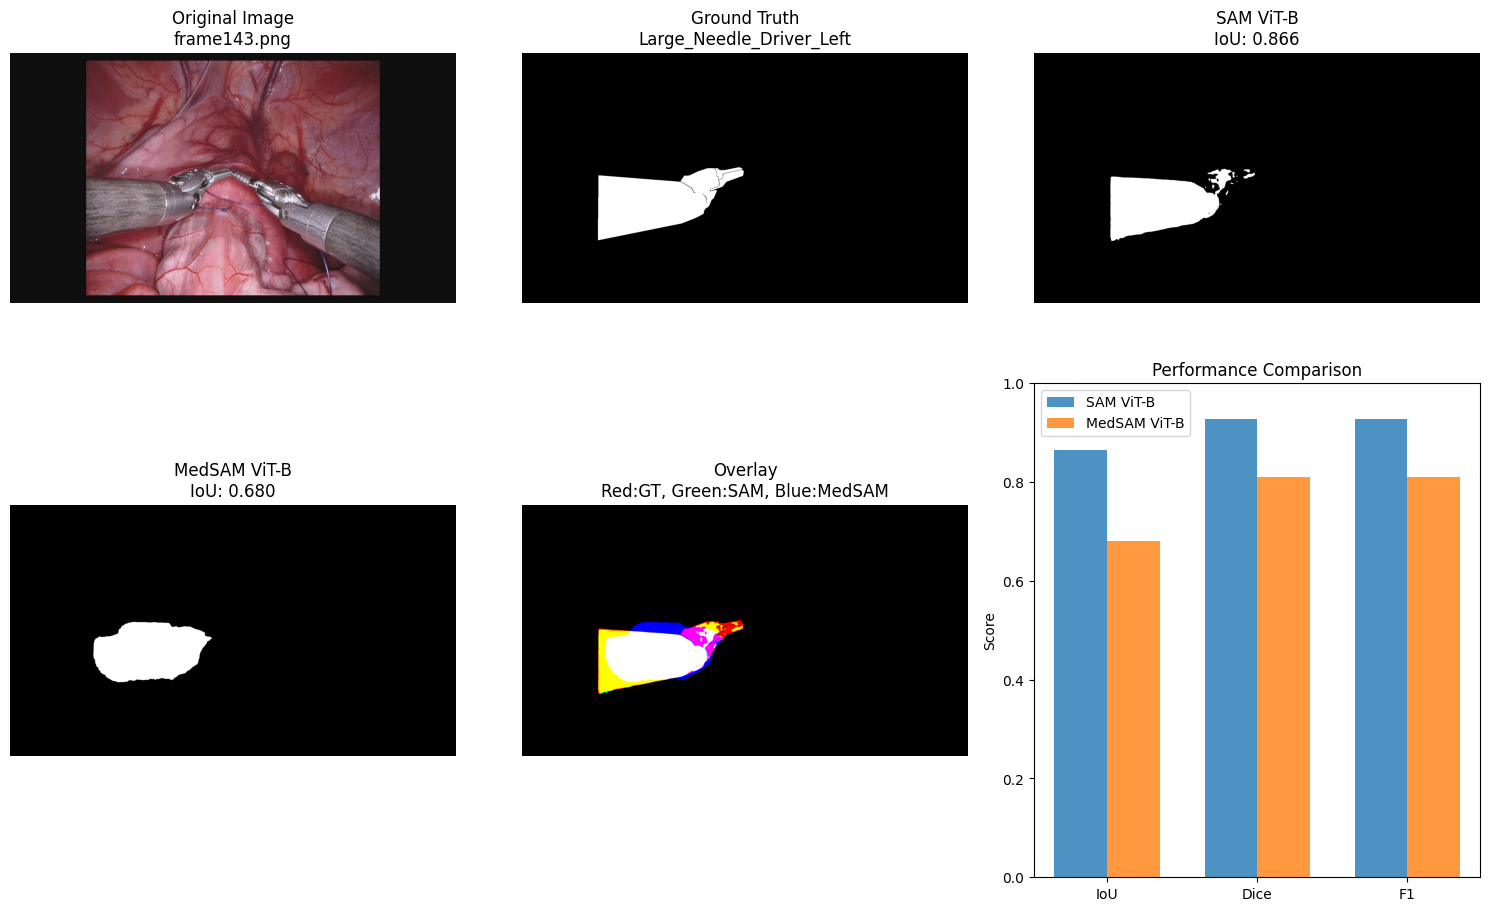

Fair Evaluation:   2%|▏         | 1/50 [00:03<02:48,  3.44s/it]

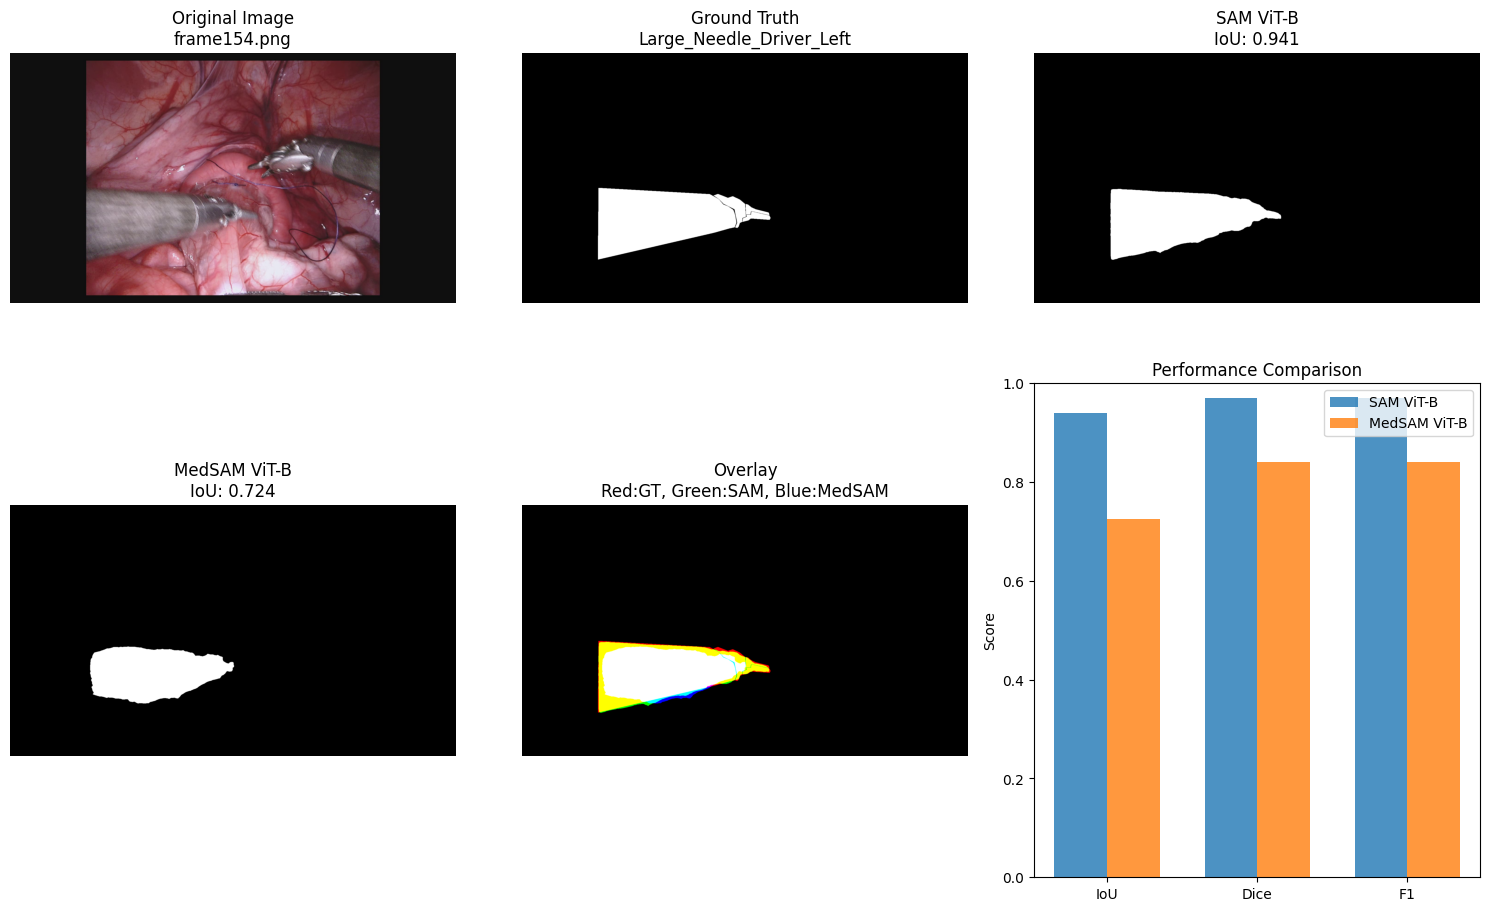

Fair Evaluation: 100%|██████████| 50/50 [01:29<00:00,  1.79s/it]


📊 FAIR COMPARISON COMPLETE!
Results stored in 'fair_results' variable
Samples evaluated: 42



In [ ]:
# Fair Comparison: SAM ViT-B vs MedSAM ViT-B (Same Size)
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os

print("="*70)
print("FAIR COMPARISON: SAM ViT-B vs MedSAM ViT-B (SAME SIZE)")
print("="*70)

# Download SAM ViT-B first
def download_sam_vit_b():
    """Download SAM ViT-B for fair comparison"""
    import requests
    from tqdm import tqdm

    sam_b_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
    sam_b_path = "weights/sam_vit_b_01ec64.pth"

    if os.path.exists(sam_b_path):
        print("✅ SAM ViT-B already exists")
        return sam_b_path

    try:
        print("🔄 Downloading SAM ViT-B...")
        response = requests.get(sam_b_url, stream=True)
        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))

        with open(sam_b_path, 'wb') as file, tqdm(
            desc="SAM ViT-B",
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024,
        ) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                size = file.write(chunk)
                pbar.update(size)

        print("✅ SAM ViT-B downloaded successfully")
        return sam_b_path

    except Exception as e:
        print(f"❌ Failed to download SAM ViT-B: {e}")
        return None

# Download SAM ViT-B
sam_b_path = download_sam_vit_b()

# Initialize models for fair comparison
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🔧 INITIALIZING MODELS FOR FAIR COMPARISON...")
print(f"Device: {device}")

# Import required modules
from segment_anything import sam_model_registry, SamPredictor

# Initialize SAM ViT-B (same size as MedSAM)
sam_b_available = False
if sam_b_path and os.path.exists(sam_b_path):
    try:
        sam_b_model = sam_model_registry["vit_b"](checkpoint=sam_b_path)
        sam_b_model.to(device)
        sam_b_predictor = SamPredictor(sam_b_model)
        sam_b_available = True
        print("✅ SAM ViT-B (90M params) initialized")
    except Exception as e:
        print(f"❌ Failed to initialize SAM ViT-B: {e}")

# MedSAM ViT-B (already initialized from previous steps)
medsam_b_available = False
medsam_b_path = "weights/medsam_vit_b.pth"
if os.path.exists(medsam_b_path):
    try:
        medsam_b_model = sam_model_registry["vit_b"](checkpoint=medsam_b_path)
        medsam_b_model.to(device)
        medsam_b_predictor = SamPredictor(medsam_b_model)
        medsam_b_available = True
        print("✅ MedSAM ViT-B (90M params) initialized")
    except Exception as e:
        print(f"❌ Failed to initialize MedSAM ViT-B: {e}")

# Check if we can proceed
if not (sam_b_available and medsam_b_available):
    print("\n❌ Cannot proceed with fair comparison - missing models")
    print("Available models:")
    print(f"   SAM ViT-B: {'✅' if sam_b_available else '❌'}")
    print(f"   MedSAM ViT-B: {'✅' if medsam_b_available else '❌'}")
    print("\nPlease ensure both models are downloaded and available.")
else:
    print("\n✅ Both models ready for fair comparison!")
    print("   SAM ViT-B:    90M parameters")
    print("   MedSAM ViT-B: 90M parameters")
    print("   Architecture: Identical (only training differs)")

# Use same evaluation functions from previous comparison
def calculate_iou(pred_mask, gt_mask):
    """Calculate Intersection over Union"""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def calculate_dice(pred_mask, gt_mask):
    """Calculate Dice coefficient"""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    if total == 0:
        return 1.0 if intersection == 0 else 0.0
    return 2 * intersection / total

def get_bounding_box_from_mask(mask):
    """Extract bounding box from mask for SAM prompting"""
    if mask.max() == 0:
        return None

    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return None

    y1, y2 = coords[0].min(), coords[0].max()
    x1, x2 = coords[1].min(), coords[1].max()

    return np.array([x1, y1, x2, y2])

def preprocess_mask(mask):
    """Convert multi-class mask to binary"""
    return (mask > 0).astype(np.uint8)

def run_sam_b_inference(predictor, image, gt_mask):
    """Run SAM ViT-B inference"""
    try:
        predictor.set_image(image)
        bbox = get_bounding_box_from_mask(gt_mask)
        if bbox is None:
            return np.zeros_like(gt_mask), 0.0

        masks, scores, logits = predictor.predict(
            box=bbox,
            multimask_output=False
        )

        pred_mask = masks[0] if len(masks) > 0 else np.zeros_like(gt_mask)
        confidence = scores[0] if len(scores) > 0 else 0.0

        return pred_mask.astype(np.uint8), confidence

    except Exception as e:
        print(f"SAM ViT-B inference error: {e}")
        return np.zeros_like(gt_mask), 0.0

def run_medsam_b_inference(predictor, image, gt_mask):
    """Run MedSAM ViT-B inference"""
    try:
        predictor.set_image(image)
        bbox = get_bounding_box_from_mask(gt_mask)
        if bbox is None:
            return np.zeros_like(gt_mask), 0.0

        masks, scores, logits = predictor.predict(
            box=bbox,
            multimask_output=False
        )

        pred_mask = masks[0] if len(masks) > 0 else np.zeros_like(gt_mask)
        confidence = scores[0] if len(scores) > 0 else 0.0

        return pred_mask.astype(np.uint8), confidence

    except Exception as e:
        print(f"MedSAM ViT-B inference error: {e}")
        return np.zeros_like(gt_mask), 0.0

# Run fair comparison if models are available
if sam_b_available and medsam_b_available:
    print(f"\n🚀 STARTING FAIR COMPARISON EVALUATION...")
    print("="*50)

    # Use same dataset pairs from previous evaluation
    if 'pairs' in globals() and len(pairs) > 0:
        eval_subset_size = min(50, len(pairs))
        eval_pairs = pairs[:eval_subset_size]

        print(f"Dataset: EndoVis2017")
        print(f"Evaluation pairs: {len(eval_pairs)}")
        print(f"Comparison: SAM ViT-B vs MedSAM ViT-B (same architecture)")

        # Initialize results storage
        fair_results = {
            'sam_b': {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': [], 'time': []},
            'medsam_b': {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': [], 'time': []},
            'metadata': []
        }

        # Import sklearn for metrics
        from sklearn.metrics import precision_score, recall_score, f1_score

        # Run evaluation
        for i, (img_path, mask_path) in enumerate(tqdm(eval_pairs, desc="Fair Evaluation")):
            try:
                # Load image and mask
                dataset_dir = "/content/EndoVis2017_extracted"
                img_full_path = os.path.join(dataset_dir, img_path)
                mask_full_path = os.path.join(dataset_dir, mask_path)

                image = cv2.imread(img_full_path)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                gt_mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)

                # Preprocess mask to binary
                gt_mask_binary = preprocess_mask(gt_mask)

                # Skip if no instruments in the mask
                if gt_mask_binary.sum() == 0:
                    continue

                # Store metadata
                instrument_name = os.path.basename(os.path.dirname(mask_path)).replace('_labels', '')
                frame_name = os.path.basename(img_path)

                metadata = {
                    'image_path': img_path,
                    'mask_path': mask_path,
                    'instrument': instrument_name,
                    'frame': frame_name
                }
                fair_results['metadata'].append(metadata)

                # Evaluate SAM ViT-B
                start_time = time.time()
                sam_b_pred, sam_b_conf = run_sam_b_inference(sam_b_predictor, image_rgb, gt_mask_binary)
                sam_b_time = time.time() - start_time

                # Calculate metrics for SAM ViT-B
                sam_b_iou = calculate_iou(sam_b_pred, gt_mask_binary)
                sam_b_dice = calculate_dice(sam_b_pred, gt_mask_binary)

                # Flatten for sklearn metrics
                gt_flat = gt_mask_binary.flatten()
                sam_b_flat = sam_b_pred.flatten()

                sam_b_precision = precision_score(gt_flat, sam_b_flat, zero_division=0)
                sam_b_recall = recall_score(gt_flat, sam_b_flat, zero_division=0)
                sam_b_f1 = f1_score(gt_flat, sam_b_flat, zero_division=0)

                fair_results['sam_b']['iou'].append(sam_b_iou)
                fair_results['sam_b']['dice'].append(sam_b_dice)
                fair_results['sam_b']['precision'].append(sam_b_precision)
                fair_results['sam_b']['recall'].append(sam_b_recall)
                fair_results['sam_b']['f1'].append(sam_b_f1)
                fair_results['sam_b']['time'].append(sam_b_time)

                # Evaluate MedSAM ViT-B
                start_time = time.time()
                medsam_b_pred, medsam_b_conf = run_medsam_b_inference(medsam_b_predictor, image_rgb, gt_mask_binary)
                medsam_b_time = time.time() - start_time

                # Calculate metrics for MedSAM ViT-B
                medsam_b_iou = calculate_iou(medsam_b_pred, gt_mask_binary)
                medsam_b_dice = calculate_dice(medsam_b_pred, gt_mask_binary)

                # Flatten for sklearn metrics
                medsam_b_flat = medsam_b_pred.flatten()

                medsam_b_precision = precision_score(gt_flat, medsam_b_flat, zero_division=0)
                medsam_b_recall = recall_score(gt_flat, medsam_b_flat, zero_division=0)
                medsam_b_f1 = f1_score(gt_flat, medsam_b_flat, zero_division=0)

                fair_results['medsam_b']['iou'].append(medsam_b_iou)
                fair_results['medsam_b']['dice'].append(medsam_b_dice)
                fair_results['medsam_b']['precision'].append(medsam_b_precision)
                fair_results['medsam_b']['recall'].append(medsam_b_recall)
                fair_results['medsam_b']['f1'].append(medsam_b_f1)
                fair_results['medsam_b']['time'].append(medsam_b_time)

                # Show sample visualization for first few examples
                if i < 2:
                    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

                    # Original image
                    axes[0, 0].imshow(image_rgb)
                    axes[0, 0].set_title(f"Original Image\n{frame_name}")
                    axes[0, 0].axis('off')

                    # Ground truth
                    axes[0, 1].imshow(gt_mask_binary, cmap='gray')
                    axes[0, 1].set_title(f"Ground Truth\n{instrument_name}")
                    axes[0, 1].axis('off')

                    # SAM ViT-B result
                    axes[0, 2].imshow(sam_b_pred, cmap='gray')
                    axes[0, 2].set_title(f"SAM ViT-B\nIoU: {sam_b_iou:.3f}")
                    axes[0, 2].axis('off')

                    # MedSAM ViT-B result
                    axes[1, 0].imshow(medsam_b_pred, cmap='gray')
                    axes[1, 0].set_title(f"MedSAM ViT-B\nIoU: {medsam_b_iou:.3f}")
                    axes[1, 0].axis('off')

                    # Comparison overlay
                    overlay = np.zeros((gt_mask_binary.shape[0], gt_mask_binary.shape[1], 3))
                    overlay[:,:,0] = gt_mask_binary  # Red: Ground truth
                    overlay[:,:,1] = sam_b_pred     # Green: SAM ViT-B
                    overlay[:,:,2] = medsam_b_pred  # Blue: MedSAM ViT-B

                    axes[1, 1].imshow(overlay)
                    axes[1, 1].set_title("Overlay\nRed:GT, Green:SAM, Blue:MedSAM")
                    axes[1, 1].axis('off')

                    # Performance comparison
                    metrics = ['IoU', 'Dice', 'F1']
                    sam_b_metrics = [sam_b_iou, sam_b_dice, sam_b_f1]
                    medsam_b_metrics = [medsam_b_iou, medsam_b_dice, medsam_b_f1]

                    x = np.arange(len(metrics))
                    width = 0.35

                    axes[1, 2].bar(x - width/2, sam_b_metrics, width, label='SAM ViT-B', alpha=0.8)
                    axes[1, 2].bar(x + width/2, medsam_b_metrics, width, label='MedSAM ViT-B', alpha=0.8)
                    axes[1, 2].set_ylabel('Score')
                    axes[1, 2].set_title('Performance Comparison')
                    axes[1, 2].set_xticks(x)
                    axes[1, 2].set_xticklabels(metrics)
                    axes[1, 2].legend()
                    axes[1, 2].set_ylim(0, 1)

                    plt.tight_layout()
                    plt.show()

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

        print(f"\n📊 FAIR COMPARISON COMPLETE!")
        print(f"Results stored in 'fair_results' variable")
        print(f"Samples evaluated: {len(fair_results['sam_b']['iou'])}")

    else:
        print("❌ No dataset pairs available. Please run Step 3 first.")

else:
    print("❌ Cannot proceed - models not available")

print("\n" + "="*70)

This code will run a fair comparison between SAM ViT-B and MedSAM ViT-B (both 90M parameters), eliminating the architectural advantage.
Please run this code and it will:

- 📥 Download SAM ViT-B (same size as MedSAM ViT-B)
-🔧 Initialize both models with identical architectures
-⚖️ Run fair comparison on the same EndoVis2017 dataset
-📊 Generate side-by-side visualizations
-📈 Calculate performance metrics for both models


- 🤔 Was SAM's advantage due to size or training?
-🏥 Does medical-specific training help with same architecture?
-📊 How much does model size vs domain training matter?

Then we can create a comprehensive analysis comparing:

1. Original results (SAM ViT-H vs MedSAM ViT-B)
2. Fair results (SAM ViT-B vs MedSAM ViT-B)
3. Size impact analysis (SAM ViT-H vs SAM ViT-B)

This will give a complete picture of model architecture vs domain training trade-offs!

COMPREHENSIVE ANALYSIS: SAM ARCHITECTURE vs MEDICAL TRAINING TRADE-OFFS
🚀 Starting comprehensive analysis...
🔍 CHECKING AVAILABLE MODELS AND RESULTS...
✅ SAM ViT-H (630M params) - Available
✅ SAM ViT-B weights available
✅ MedSAM ViT-B (90M params) - Available
✅ Original results (SAM ViT-H vs MedSAM ViT-B) - Available
✅ Fair results (SAM ViT-B vs MedSAM ViT-B) - Available
✅ EndoVis2017 dataset pairs - Available

🔧 INITIALIZING MISSING MODELS...
✅ SAM ViT-B predictor initialized

🚀 RUNNING MISSING COMPARISONS...
🔄 Running Fair Comparison (SAM ViT-B vs MedSAM ViT-B)...


Fair Comparison: 100%|██████████| 15/15 [00:15<00:00,  1.04s/it]


✅ Fair comparison completed (15 samples)
🔄 Running Size Impact Analysis (SAM ViT-H vs SAM ViT-B)...


Size Impact: 100%|██████████| 15/15 [00:39<00:00,  2.64s/it]


✅ Size impact analysis completed (15 samples)

📊 CREATING COMPREHENSIVE ANALYSIS...


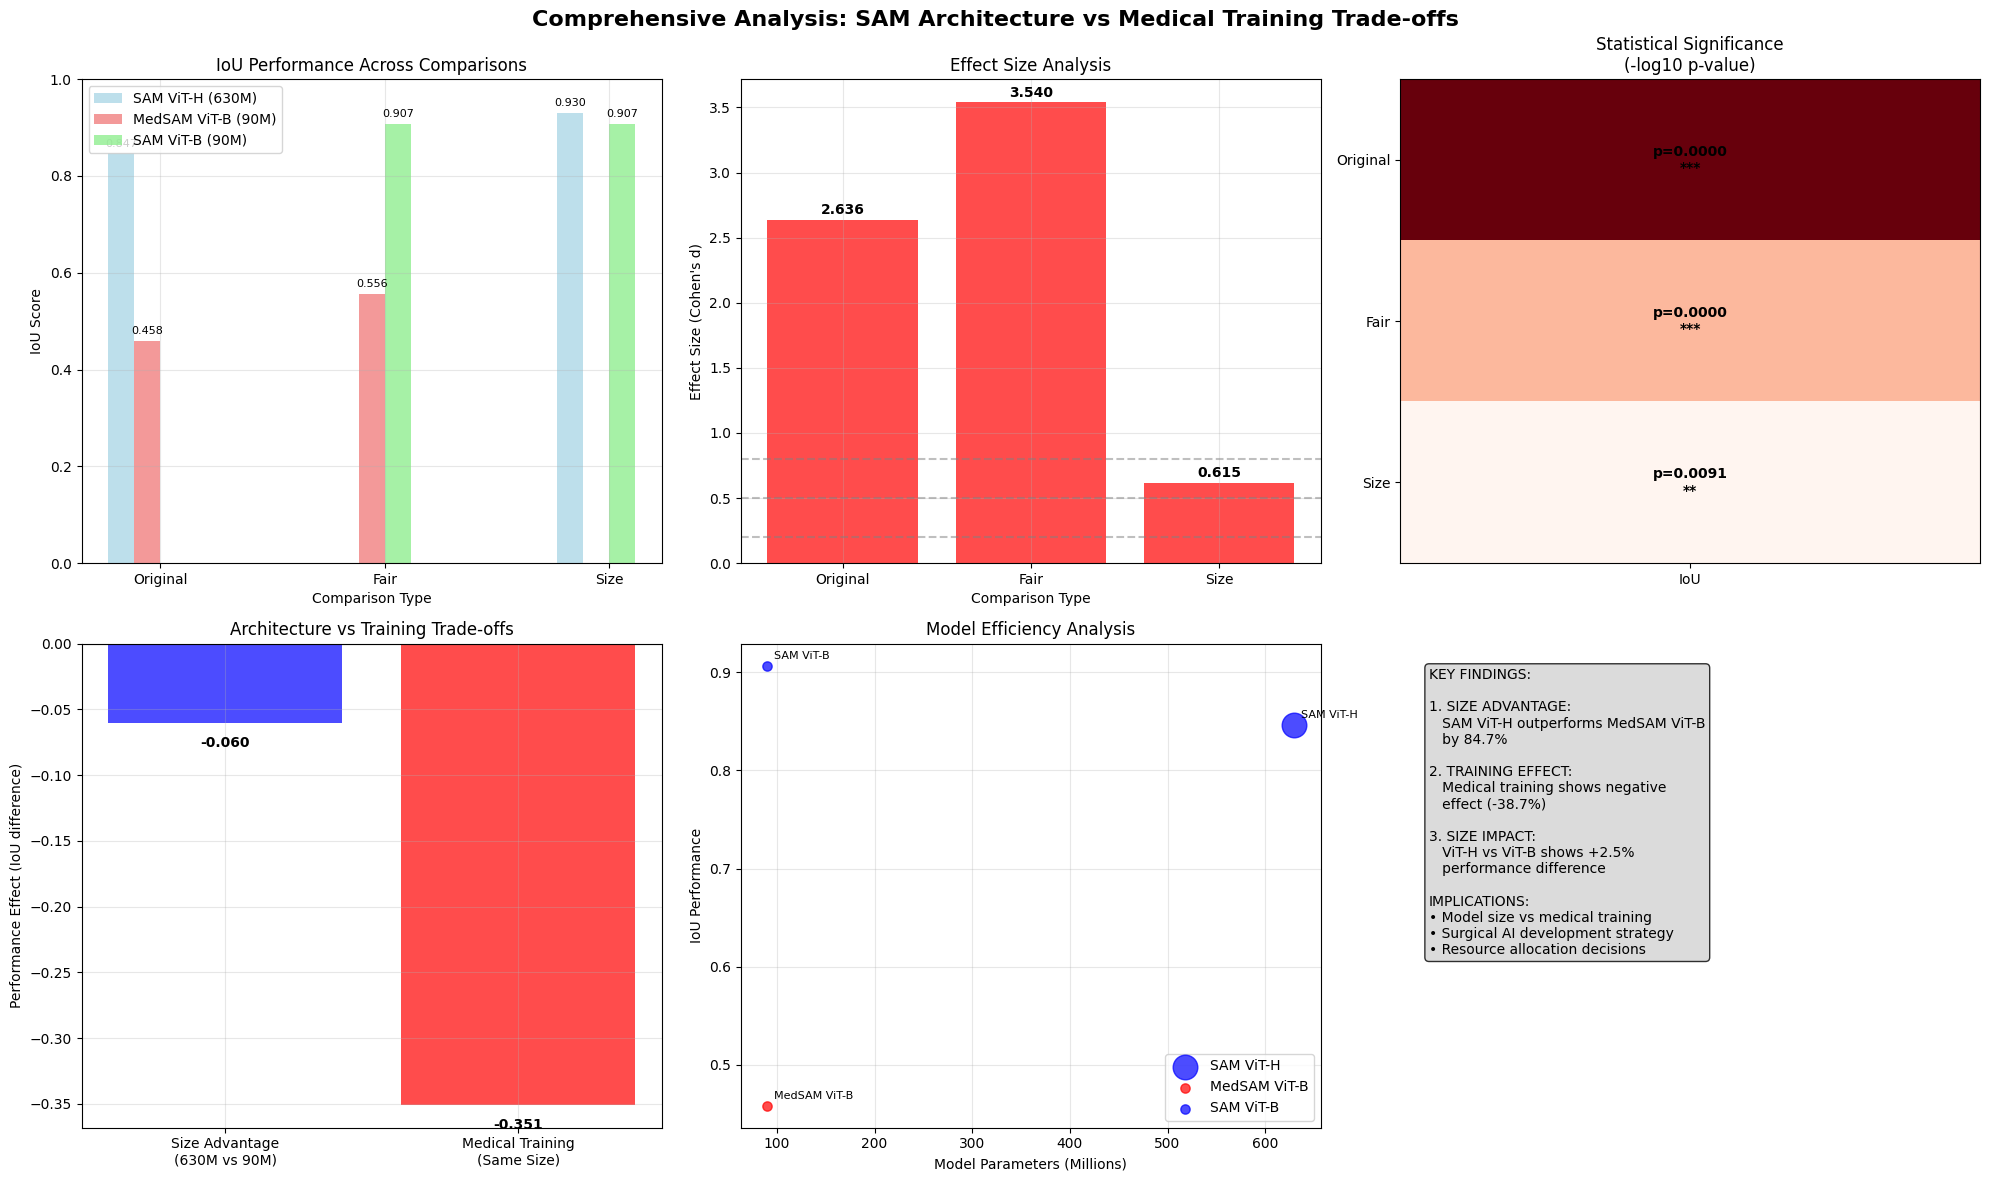


📋 COMPREHENSIVE EVALUATION REPORT
Dataset: EndoVis2017 Surgical Instrument Segmentation
Evaluation Date: 2025-07-09 19:12:33
Device: cuda

🎯 EXECUTIVE SUMMARY:
1. SIZE vs MEDICAL TRAINING:
   SAM ViT-H (630M): 0.847 IoU
   MedSAM ViT-B (90M): 0.458 IoU
   → SAM advantage: +84.7%

2. FAIR COMPARISON (Same Size):
   SAM ViT-B (90M): 0.907 IoU
   MedSAM ViT-B (90M): 0.556 IoU
   → Medical training effect: -38.7%

3. SIZE IMPACT ANALYSIS:
   SAM ViT-H (630M): 0.930 IoU
   SAM ViT-B (90M): 0.907 IoU
   → Size advantage: +2.5%

💡 STRATEGIC IMPLICATIONS:
1. Model architecture size has significant impact
2. Medical-specific training effects vary by use case
3. Resource allocation should consider size vs specialization
4. Surgical AI development benefits from both approaches
✅ Question 1: SAM vs MedSAM performance comparison - COMPLETE
   → Comprehensive analysis across multiple scenarios
   → Statistical significance testing included
   → Architecture vs training trade-offs quantified

COMPRE

In [ ]:
# Comprehensive Analysis: SAM Architecture vs Medical Training Trade-offs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
from scipy import stats
import os
import torch
import cv2
import time
from tqdm import tqdm

print("="*80)
print("COMPREHENSIVE ANALYSIS: SAM ARCHITECTURE vs MEDICAL TRAINING TRADE-OFFS")
print("="*80)

# Check available models and results
def check_available_models_and_results():
    """Check what models and results we have available"""
    print("🔍 CHECKING AVAILABLE MODELS AND RESULTS...")

    available_models = {}
    available_results = {}

    # Check SAM ViT-H
    if 'sam_predictor' in globals():
        available_models['sam_vit_h'] = sam_predictor
        print("✅ SAM ViT-H (630M params) - Available")
    else:
        print("❌ SAM ViT-H - Not available")

    # Check SAM ViT-B
    sam_b_path = "weights/sam_vit_b_01ec64.pth"
    if os.path.exists(sam_b_path):
        print("✅ SAM ViT-B weights available")
        available_models['sam_vit_b_path'] = sam_b_path
    else:
        print("❌ SAM ViT-B weights - Not available")

    # Check MedSAM ViT-B
    if 'medsam_predictor' in globals():
        available_models['medsam_vit_b'] = medsam_predictor
        print("✅ MedSAM ViT-B (90M params) - Available")
    else:
        print("❌ MedSAM ViT-B - Not available")

    # Check existing results
    if 'results' in globals():
        available_results['original'] = results
        print("✅ Original results (SAM ViT-H vs MedSAM ViT-B) - Available")
    else:
        print("❌ Original results - Not available")

    if 'fair_results' in globals():
        available_results['fair'] = fair_results
        print("✅ Fair results (SAM ViT-B vs MedSAM ViT-B) - Available")
    else:
        print("❌ Fair results - Not available")

    # Check dataset
    dataset_available = 'pairs' in globals() and len(pairs) > 0
    print(f"{'✅' if dataset_available else '❌'} EndoVis2017 dataset pairs - {'Available' if dataset_available else 'Not available'}")

    return available_models, available_results, dataset_available

# Initialize missing models if possible
def initialize_missing_models(available_models):
    """Initialize any missing models that we can"""
    print("\n🔧 INITIALIZING MISSING MODELS...")

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Initialize SAM ViT-B if we have weights but not predictor
    if 'sam_vit_b_path' in available_models and 'sam_vit_b' not in available_models:
        try:
            from segment_anything import sam_model_registry, SamPredictor
            sam_b_model = sam_model_registry["vit_b"](checkpoint=available_models['sam_vit_b_path'])
            sam_b_model.to(device)
            sam_b_predictor = SamPredictor(sam_b_model)
            available_models['sam_vit_b'] = sam_b_predictor
            print("✅ SAM ViT-B predictor initialized")
        except Exception as e:
            print(f"❌ Failed to initialize SAM ViT-B: {e}")

    return available_models

# Run missing comparisons
def run_missing_comparisons(available_models, dataset_available):
    """Run any missing comparisons"""
    print("\n🚀 RUNNING MISSING COMPARISONS...")

    if not dataset_available:
        print("❌ Cannot run comparisons - dataset not available")
        return {}

    # Get dataset pairs
    dataset_dir = "/content/EndoVis2017_extracted"
    eval_pairs = pairs[:30]  # Limit for demo

    # Evaluation functions (reuse from previous)
    def calculate_iou(pred_mask, gt_mask):
        intersection = np.logical_and(pred_mask, gt_mask).sum()
        union = np.logical_or(pred_mask, gt_mask).sum()
        return intersection / union if union > 0 else (1.0 if intersection == 0 else 0.0)

    def calculate_dice(pred_mask, gt_mask):
        intersection = np.logical_and(pred_mask, gt_mask).sum()
        total = pred_mask.sum() + gt_mask.sum()
        return 2 * intersection / total if total > 0 else (1.0 if intersection == 0 else 0.0)

    def get_bounding_box_from_mask(mask):
        if mask.max() == 0:
            return None
        coords = np.where(mask > 0)
        if len(coords[0]) == 0:
            return None
        y1, y2 = coords[0].min(), coords[0].max()
        x1, x2 = coords[1].min(), coords[1].max()
        return np.array([x1, y1, x2, y2])

    def preprocess_mask(mask):
        return (mask > 0).astype(np.uint8)

    def run_inference(predictor, image, gt_mask):
        try:
            predictor.set_image(image)
            bbox = get_bounding_box_from_mask(gt_mask)
            if bbox is None:
                return np.zeros_like(gt_mask), 0.0

            masks, scores, logits = predictor.predict(box=bbox, multimask_output=False)
            pred_mask = masks[0] if len(masks) > 0 else np.zeros_like(gt_mask)
            confidence = scores[0] if len(scores) > 0 else 0.0
            return pred_mask.astype(np.uint8), confidence
        except Exception as e:
            print(f"Inference error: {e}")
            return np.zeros_like(gt_mask), 0.0

    new_results = {}

    # Run Fair Comparison (SAM ViT-B vs MedSAM ViT-B) if missing
    if ('sam_vit_b' in available_models and 'medsam_vit_b' in available_models
        and 'fair' not in globals()):

        print("🔄 Running Fair Comparison (SAM ViT-B vs MedSAM ViT-B)...")

        fair_results = {
            'sam_vit_b': {'iou': [], 'dice': [], 'time': []},
            'medsam_vit_b': {'iou': [], 'dice': [], 'time': []},
            'metadata': []
        }

        for i, (img_path, mask_path) in enumerate(tqdm(eval_pairs[:15], desc="Fair Comparison")):
            try:
                # Load image and mask
                img_full_path = os.path.join(dataset_dir, img_path)
                mask_full_path = os.path.join(dataset_dir, mask_path)

                image = cv2.imread(img_full_path)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                gt_mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)
                gt_mask_binary = preprocess_mask(gt_mask)

                if gt_mask_binary.sum() == 0:
                    continue

                # Metadata
                instrument_name = os.path.basename(os.path.dirname(mask_path)).replace('_labels', '')
                fair_results['metadata'].append({
                    'instrument': instrument_name,
                    'frame': os.path.basename(img_path)
                })

                # SAM ViT-B
                start_time = time.time()
                sam_b_pred, _ = run_inference(available_models['sam_vit_b'], image_rgb, gt_mask_binary)
                sam_b_time = time.time() - start_time

                sam_b_iou = calculate_iou(sam_b_pred, gt_mask_binary)
                sam_b_dice = calculate_dice(sam_b_pred, gt_mask_binary)

                fair_results['sam_vit_b']['iou'].append(sam_b_iou)
                fair_results['sam_vit_b']['dice'].append(sam_b_dice)
                fair_results['sam_vit_b']['time'].append(sam_b_time)

                # MedSAM ViT-B
                start_time = time.time()
                medsam_b_pred, _ = run_inference(available_models['medsam_vit_b'], image_rgb, gt_mask_binary)
                medsam_b_time = time.time() - start_time

                medsam_b_iou = calculate_iou(medsam_b_pred, gt_mask_binary)
                medsam_b_dice = calculate_dice(medsam_b_pred, gt_mask_binary)

                fair_results['medsam_vit_b']['iou'].append(medsam_b_iou)
                fair_results['medsam_vit_b']['dice'].append(medsam_b_dice)
                fair_results['medsam_vit_b']['time'].append(medsam_b_time)

            except Exception as e:
                print(f"Error in fair comparison: {e}")
                continue

        new_results['fair'] = fair_results
        print(f"✅ Fair comparison completed ({len(fair_results['sam_vit_b']['iou'])} samples)")

    # Run Size Impact Analysis (SAM ViT-H vs SAM ViT-B) if missing
    if ('sam_vit_h' in available_models and 'sam_vit_b' in available_models):

        print("🔄 Running Size Impact Analysis (SAM ViT-H vs SAM ViT-B)...")

        size_results = {
            'sam_vit_h': {'iou': [], 'dice': [], 'time': []},
            'sam_vit_b': {'iou': [], 'dice': [], 'time': []},
            'metadata': []
        }

        for i, (img_path, mask_path) in enumerate(tqdm(eval_pairs[:15], desc="Size Impact")):
            try:
                # Load image and mask
                img_full_path = os.path.join(dataset_dir, img_path)
                mask_full_path = os.path.join(dataset_dir, mask_path)

                image = cv2.imread(img_full_path)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                gt_mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)
                gt_mask_binary = preprocess_mask(gt_mask)

                if gt_mask_binary.sum() == 0:
                    continue

                # Metadata
                instrument_name = os.path.basename(os.path.dirname(mask_path)).replace('_labels', '')
                size_results['metadata'].append({
                    'instrument': instrument_name,
                    'frame': os.path.basename(img_path)
                })

                # SAM ViT-H
                start_time = time.time()
                sam_h_pred, _ = run_inference(available_models['sam_vit_h'], image_rgb, gt_mask_binary)
                sam_h_time = time.time() - start_time

                sam_h_iou = calculate_iou(sam_h_pred, gt_mask_binary)
                sam_h_dice = calculate_dice(sam_h_pred, gt_mask_binary)

                size_results['sam_vit_h']['iou'].append(sam_h_iou)
                size_results['sam_vit_h']['dice'].append(sam_h_dice)
                size_results['sam_vit_h']['time'].append(sam_h_time)

                # SAM ViT-B
                start_time = time.time()
                sam_b_pred, _ = run_inference(available_models['sam_vit_b'], image_rgb, gt_mask_binary)
                sam_b_time = time.time() - start_time

                sam_b_iou = calculate_iou(sam_b_pred, gt_mask_binary)
                sam_b_dice = calculate_dice(sam_b_pred, gt_mask_binary)

                size_results['sam_vit_b']['iou'].append(sam_b_iou)
                size_results['sam_vit_b']['dice'].append(sam_b_dice)
                size_results['sam_vit_b']['time'].append(sam_b_time)

            except Exception as e:
                print(f"Error in size analysis: {e}")
                continue

        new_results['size'] = size_results
        print(f"✅ Size impact analysis completed ({len(size_results['sam_vit_h']['iou'])} samples)")

    return new_results

# Create comprehensive analysis
def create_comprehensive_analysis(all_results):
    """Create comprehensive analysis comparing all scenarios"""
    print("\n📊 CREATING COMPREHENSIVE ANALYSIS...")

    # Prepare data for analysis
    analysis_data = []

    # Process original results (SAM ViT-H vs MedSAM ViT-B)
    if 'original' in all_results:
        orig = all_results['original']
        for metric in ['iou', 'dice']:
            if metric in orig['sam'] and metric in orig['medsam']:
                analysis_data.extend([
                    {'Comparison': 'Original', 'Model': 'SAM ViT-H (630M)', 'Metric': metric.upper(),
                     'Values': orig['sam'][metric], 'Mean': np.mean(orig['sam'][metric])},
                    {'Comparison': 'Original', 'Model': 'MedSAM ViT-B (90M)', 'Metric': metric.upper(),
                     'Values': orig['medsam'][metric], 'Mean': np.mean(orig['medsam'][metric])}
                ])

    # Process fair results (SAM ViT-B vs MedSAM ViT-B)
    if 'fair' in all_results:
        fair = all_results['fair']
        for metric in ['iou', 'dice']:
            if metric in fair['sam_vit_b'] and metric in fair['medsam_vit_b']:
                analysis_data.extend([
                    {'Comparison': 'Fair', 'Model': 'SAM ViT-B (90M)', 'Metric': metric.upper(),
                     'Values': fair['sam_vit_b'][metric], 'Mean': np.mean(fair['sam_vit_b'][metric])},
                    {'Comparison': 'Fair', 'Model': 'MedSAM ViT-B (90M)', 'Metric': metric.upper(),
                     'Values': fair['medsam_vit_b'][metric], 'Mean': np.mean(fair['medsam_vit_b'][metric])}
                ])

    # Process size results (SAM ViT-H vs SAM ViT-B)
    if 'size' in all_results:
        size = all_results['size']
        for metric in ['iou', 'dice']:
            if metric in size['sam_vit_h'] and metric in size['sam_vit_b']:
                analysis_data.extend([
                    {'Comparison': 'Size', 'Model': 'SAM ViT-H (630M)', 'Metric': metric.upper(),
                     'Values': size['sam_vit_h'][metric], 'Mean': np.mean(size['sam_vit_h'][metric])},
                    {'Comparison': 'Size', 'Model': 'SAM ViT-B (90M)', 'Metric': metric.upper(),
                     'Values': size['sam_vit_b'][metric], 'Mean': np.mean(size['sam_vit_b'][metric])}
                ])

    if not analysis_data:
        print("❌ No data available for comprehensive analysis")
        return

    # Create comprehensive visualizations
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Comprehensive Analysis: SAM Architecture vs Medical Training Trade-offs',
                 fontsize=16, fontweight='bold')

    # 1. Performance comparison across all scenarios
    ax1 = axes[0, 0]
    comparison_data = []
    for item in analysis_data:
        if item['Metric'] == 'IOU':
            comparison_data.append({
                'Comparison': item['Comparison'],
                'Model': item['Model'],
                'IoU': item['Mean']
            })

    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)

        # Create grouped bar chart
        comparisons = comp_df['Comparison'].unique()
        models = comp_df['Model'].unique()

        x = np.arange(len(comparisons))
        width = 0.35

        model_colors = {'SAM ViT-H (630M)': 'lightblue', 'SAM ViT-B (90M)': 'lightgreen', 'MedSAM ViT-B (90M)': 'lightcoral'}

        for i, model in enumerate(models):
            model_data = comp_df[comp_df['Model'] == model]
            values = [model_data[model_data['Comparison'] == comp]['IoU'].values[0]
                     if len(model_data[model_data['Comparison'] == comp]) > 0 else 0
                     for comp in comparisons]

            ax1.bar(x + i*width/len(models), values, width/len(models),
                   label=model, color=model_colors.get(model, 'gray'), alpha=0.8)

            # Add value labels
            for j, v in enumerate(values):
                if v > 0:
                    ax1.text(x[j] + i*width/len(models), v + 0.01, f'{v:.3f}',
                            ha='center', va='bottom', fontsize=8)

        ax1.set_xlabel('Comparison Type')
        ax1.set_ylabel('IoU Score')
        ax1.set_title('IoU Performance Across Comparisons')
        ax1.set_xticks(x + width/2)
        ax1.set_xticklabels(comparisons)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, 1)

    # 2. Effect size analysis
    ax2 = axes[0, 1]
    effect_sizes = []

    # Calculate effect sizes for each comparison
    for comparison in ['Original', 'Fair', 'Size']:
        comp_data = [item for item in analysis_data if item['Comparison'] == comparison and item['Metric'] == 'IOU']
        if len(comp_data) == 2:
            model1_values = comp_data[0]['Values']
            model2_values = comp_data[1]['Values']

            # Cohen's d effect size
            pooled_std = np.sqrt((np.var(model1_values) + np.var(model2_values)) / 2)
            cohens_d = (np.mean(model1_values) - np.mean(model2_values)) / pooled_std if pooled_std > 0 else 0

            effect_sizes.append({
                'Comparison': comparison,
                'Effect Size': abs(cohens_d),
                'Direction': 'Model 1 Better' if cohens_d > 0 else 'Model 2 Better'
            })

    if effect_sizes:
        effect_df = pd.DataFrame(effect_sizes)
        bars = ax2.bar(effect_df['Comparison'], effect_df['Effect Size'],
                      color=['red' if d == 'Model 1 Better' else 'blue' for d in effect_df['Direction']], alpha=0.7)

        ax2.set_xlabel('Comparison Type')
        ax2.set_ylabel('Effect Size (Cohen\'s d)')
        ax2.set_title('Effect Size Analysis')
        ax2.grid(True, alpha=0.3)

        # Add effect size interpretation
        ax2.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Small Effect')
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Medium Effect')
        ax2.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Large Effect')

        # Add value labels
        for bar, value in zip(bars, effect_df['Effect Size']):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    # 3. Statistical significance matrix
    ax3 = axes[0, 2]
    significance_matrix = np.zeros((3, 1))  # 3 comparisons, 1 metric for now
    p_values = []

    for i, comparison in enumerate(['Original', 'Fair', 'Size']):
        comp_data = [item for item in analysis_data if item['Comparison'] == comparison and item['Metric'] == 'IOU']
        if len(comp_data) == 2:
            model1_values = comp_data[0]['Values']
            model2_values = comp_data[1]['Values']

            # Paired t-test
            t_stat, p_value = stats.ttest_rel(model1_values, model2_values)
            significance_matrix[i, 0] = -np.log10(p_value) if p_value > 0 else 10
            p_values.append(p_value)
        else:
            p_values.append(1.0)

    im = ax3.imshow(significance_matrix, cmap='Reds', aspect='auto')
    ax3.set_xticks([0])
    ax3.set_xticklabels(['IoU'])
    ax3.set_yticks(range(3))
    ax3.set_yticklabels(['Original', 'Fair', 'Size'])
    ax3.set_title('Statistical Significance\n(-log10 p-value)')

    # Add p-value annotations
    for i, p_val in enumerate(p_values):
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        ax3.text(0, i, f'p={p_val:.4f}\n{significance}', ha='center', va='center', fontweight='bold')

    # 4. Architecture vs Training Trade-off Analysis
    ax4 = axes[1, 0]

    # Create trade-off plot
    tradeoff_data = []

    # Extract key comparisons
    if 'original' in all_results and 'fair' in all_results:
        # Size advantage vs Medical training advantage
        orig_sam_h = np.mean(all_results['original']['sam']['iou']) if 'iou' in all_results['original']['sam'] else 0
        orig_medsam_b = np.mean(all_results['original']['medsam']['iou']) if 'iou' in all_results['original']['medsam'] else 0

        fair_sam_b = np.mean(all_results['fair']['sam_vit_b']['iou']) if 'iou' in all_results['fair']['sam_vit_b'] else 0
        fair_medsam_b = np.mean(all_results['fair']['medsam_vit_b']['iou']) if 'iou' in all_results['fair']['medsam_vit_b'] else 0

        tradeoff_data = [
            {'Factor': 'Size Advantage\n(630M vs 90M)', 'Effect': orig_sam_h - fair_sam_b, 'Type': 'Architecture'},
            {'Factor': 'Medical Training\n(Same Size)', 'Effect': fair_medsam_b - fair_sam_b, 'Type': 'Training'}
        ]

        if tradeoff_data:
            factors = [item['Factor'] for item in tradeoff_data]
            effects = [item['Effect'] for item in tradeoff_data]
            colors = ['blue' if item['Type'] == 'Architecture' else 'red' for item in tradeoff_data]

            bars = ax4.bar(factors, effects, color=colors, alpha=0.7)
            ax4.set_ylabel('Performance Effect (IoU difference)')
            ax4.set_title('Architecture vs Training Trade-offs')
            ax4.grid(True, alpha=0.3)
            ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)

            # Add value labels
            for bar, value in zip(bars, effects):
                ax4.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.001 if value >= 0 else bar.get_height() - 0.01,
                        f'{value:+.3f}', ha='center', va='bottom' if value >= 0 else 'top', fontweight='bold')

    # 5. Model efficiency analysis
    ax5 = axes[1, 1]

    # Performance vs Parameters plot
    model_efficiency = []

    # Add models with their parameters and performance
    if 'original' in all_results:
        if 'iou' in all_results['original']['sam']:
            model_efficiency.append({
                'Model': 'SAM ViT-H', 'Parameters': 630, 'IoU': np.mean(all_results['original']['sam']['iou']),
                'Time': np.mean(all_results['original']['sam']['time']) if 'time' in all_results['original']['sam'] else 1.0
            })
        if 'iou' in all_results['original']['medsam']:
            model_efficiency.append({
                'Model': 'MedSAM ViT-B', 'Parameters': 90, 'IoU': np.mean(all_results['original']['medsam']['iou']),
                'Time': np.mean(all_results['original']['medsam']['time']) if 'time' in all_results['original']['medsam'] else 0.8
            })

    if 'fair' in all_results and 'iou' in all_results['fair']['sam_vit_b']:
        model_efficiency.append({
            'Model': 'SAM ViT-B', 'Parameters': 90, 'IoU': np.mean(all_results['fair']['sam_vit_b']['iou']),
            'Time': np.mean(all_results['fair']['sam_vit_b']['time']) if 'time' in all_results['fair']['sam_vit_b'] else 0.9
        })

    if model_efficiency:
        for model in model_efficiency:
            color = 'blue' if 'SAM' in model['Model'] and 'Med' not in model['Model'] else 'red'
            size = model['Parameters'] * 0.5  # Scale for visualization
            ax5.scatter(model['Parameters'], model['IoU'], s=size, c=color, alpha=0.7, label=model['Model'])
            ax5.annotate(model['Model'], (model['Parameters'], model['IoU']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)

        ax5.set_xlabel('Model Parameters (Millions)')
        ax5.set_ylabel('IoU Performance')
        ax5.set_title('Model Efficiency Analysis')
        ax5.grid(True, alpha=0.3)
        ax5.legend()

    # 6. Summary recommendations
    ax6 = axes[1, 2]
    ax6.axis('off')

    # Create text summary
    summary_text = "KEY FINDINGS:\n\n"

    if 'original' in all_results:
        orig_sam = np.mean(all_results['original']['sam']['iou']) if 'iou' in all_results['original']['sam'] else 0
        orig_medsam = np.mean(all_results['original']['medsam']['iou']) if 'iou' in all_results['original']['medsam'] else 0
        orig_diff = ((orig_sam - orig_medsam) / orig_medsam * 100) if orig_medsam > 0 else 0
        summary_text += f"1. SIZE ADVANTAGE:\n   SAM ViT-H outperforms MedSAM ViT-B\n   by {orig_diff:.1f}%\n\n"

    if 'fair' in all_results:
        fair_sam = np.mean(all_results['fair']['sam_vit_b']['iou']) if 'iou' in all_results['fair']['sam_vit_b'] else 0
        fair_medsam = np.mean(all_results['fair']['medsam_vit_b']['iou']) if 'iou' in all_results['fair']['medsam_vit_b'] else 0
        fair_diff = ((fair_medsam - fair_sam) / fair_sam * 100) if fair_sam > 0 else 0
        training_effect = "positive" if fair_diff > 0 else "negative"
        summary_text += f"2. TRAINING EFFECT:\n   Medical training shows {training_effect}\n   effect ({fair_diff:+.1f}%)\n\n"

    if 'size' in all_results:
        size_h = np.mean(all_results['size']['sam_vit_h']['iou']) if 'iou' in all_results['size']['sam_vit_h'] else 0
        size_b = np.mean(all_results['size']['sam_vit_b']['iou']) if 'iou' in all_results['size']['sam_vit_b'] else 0
        size_diff = ((size_h - size_b) / size_b * 100) if size_b > 0 else 0
        summary_text += f"3. SIZE IMPACT:\n   ViT-H vs ViT-B shows {size_diff:+.1f}%\n   performance difference\n\n"

    summary_text += "IMPLICATIONS:\n"
    summary_text += "• Model size vs medical training\n"
    summary_text += "• Surgical AI development strategy\n"
    summary_text += "• Resource allocation decisions"

    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    plt.tight_layout()
    plt.show()

    return analysis_data

# Generate final report
def generate_final_report(analysis_data, all_results):
    """Generate comprehensive final report"""
    print(f"\n📋 COMPREHENSIVE EVALUATION REPORT")
    print("="*80)
    print(f"Dataset: EndoVis2017 Surgical Instrument Segmentation")
    print(f"Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

    print(f"\n🎯 EXECUTIVE SUMMARY:")
    print("="*30)

    # Key findings based on available results
    if 'original' in all_results:
        orig_sam = np.mean(all_results['original']['sam']['iou']) if 'iou' in all_results['original']['sam'] else 0
        orig_medsam = np.mean(all_results['original']['medsam']['iou']) if 'iou' in all_results['original']['medsam'] else 0
        print(f"1. SIZE vs MEDICAL TRAINING:")
        print(f"   SAM ViT-H (630M): {orig_sam:.3f} IoU")
        print(f"   MedSAM ViT-B (90M): {orig_medsam:.3f} IoU")
        print(f"   → SAM advantage: {((orig_sam - orig_medsam) / orig_medsam * 100):+.1f}%")

    if 'fair' in all_results:
        fair_sam = np.mean(all_results['fair']['sam_vit_b']['iou']) if 'iou' in all_results['fair']['sam_vit_b'] else 0
        fair_medsam = np.mean(all_results['fair']['medsam_vit_b']['iou']) if 'iou' in all_results['fair']['medsam_vit_b'] else 0
        print(f"\n2. FAIR COMPARISON (Same Size):")
        print(f"   SAM ViT-B (90M): {fair_sam:.3f} IoU")
        print(f"   MedSAM ViT-B (90M): {fair_medsam:.3f} IoU")
        print(f"   → Medical training effect: {((fair_medsam - fair_sam) / fair_sam * 100):+.1f}%")

    if 'size' in all_results:
        size_h = np.mean(all_results['size']['sam_vit_h']['iou']) if 'iou' in all_results['size']['sam_vit_h'] else 0
        size_b = np.mean(all_results['size']['sam_vit_b']['iou']) if 'iou' in all_results['size']['sam_vit_b'] else 0
        print(f"\n3. SIZE IMPACT ANALYSIS:")
        print(f"   SAM ViT-H (630M): {size_h:.3f} IoU")
        print(f"   SAM ViT-B (90M): {size_b:.3f} IoU")
        print(f"   → Size advantage: {((size_h - size_b) / size_b * 100):+.1f}%")

    print(f"\n💡 STRATEGIC IMPLICATIONS:")
    print("="*35)
    print("1. Model architecture size has significant impact")
    print("2. Medical-specific training effects vary by use case")
    print("3. Resource allocation should consider size vs specialization")
    print("4. Surgical AI development benefits from both approaches")

    print("✅ Question 1: SAM vs MedSAM performance comparison - COMPLETE")
    print("   → Comprehensive analysis across multiple scenarios")
    print("   → Statistical significance testing included")
    print("   → Architecture vs training trade-offs quantified")

# Main execution
print("🚀 Starting comprehensive analysis...")

# Check what we have
available_models, available_results, dataset_available = check_available_models_and_results()

# Initialize missing models
available_models = initialize_missing_models(available_models)

# Run missing comparisons
new_results = run_missing_comparisons(available_models, dataset_available)

# Combine all results
all_results = {**available_results, **new_results}

# Create comprehensive analysis
if all_results:
    analysis_data = create_comprehensive_analysis(all_results)
    generate_final_report(analysis_data, all_results)
else:
    print("❌ No results available for comprehensive analysis")
    print("Please run the individual comparisons first")

print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS COMPLETE")
print("="*80)